# Understanding What Drives Profit Margin in Commercial Roofing Projects: A Southwest Florida Demonstration

Commercial roofing contractors can have a full backlog and still end up taking work that weakens overall margin. Revenue matters, but revenue by itself does not tell us whether the company is choosing, pricing, and executing the right jobs.

The main question I wanted this notebook to explore is:

> After accounting for job size, customer type, project type, location, and execution issues, which factors tend to be associated with stronger or weaker profit margins?

**Note on the data:** this is a synthetic demonstration dataset, not actual company data. I built it to show what this type of analysis can look like and how the business questions can be framed. Any real pricing, staffing, marketing, or business-development decisions would need to be based on the contractor's actual estimating, job-costing, accounting, customer, operating, and lead-generation data.

## 1. Setup

This notebook uses standard Python analytics libraries. The random seed is fixed so the synthetic dataset can be regenerated consistently.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from textwrap import wrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import statsmodels.formula.api as smf

from sklearn.metrics import mean_absolute_error, r2_score

SEED = 42
rng = np.random.default_rng(SEED)

OUTPUT_CSV = Path("synthetic_swfl_commercial_roofing_projects.csv")

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "figure.figsize": (12, 7),
    "axes.titlesize": 18,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 140,
})

PALETTE = {
    "navy": "#1f3a5f",
    "blue": "#3b82f6",
    "teal": "#0f766e",
    "green": "#16a34a",
    "gold": "#d97706",
    "red": "#dc2626",
    "gray": "#64748b",
    "light": "#e2e8f0",
}


def dollars(x, pos=None):
    if abs(x) >= 1_000_000:
        return f"${x/1_000_000:.1f}M"
    if abs(x) >= 1_000:
        return f"${x/1_000:.0f}K"
    return f"${x:,.0f}"


def pct(x, pos=None):
    return f"{x:.0%}"


def pp(x):
    return f"{x:.1f} pts"


def clean_axis(ax, title=None, xlabel=None, ylabel=None):
    if title:
        ax.set_title(title, loc="left", pad=14)
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    ax.grid(axis="y", color="#e5e7eb", linewidth=0.8)
    ax.grid(axis="x", visible=False)
    return ax


def add_bar_labels(ax, fmt="{:.1%}", padding=0.003, fontsize=9):
    for patch in ax.patches:
        width = patch.get_width()
        ax.text(
            width + padding,
            patch.get_y() + patch.get_height() / 2,
            fmt.format(width),
            va="center",
            ha="left",
            fontsize=fontsize,
            color="#334155",
        )

## 2. Generate the Synthetic Dataset

The dataset below represents a plausible portfolio of about 500 completed commercial roofing projects in Southwest Florida from 2019 through 2025.

The data is synthetic, but it is not just random noise. The generator includes business patterns that should feel familiar: scale effects, material differences, storm-related demand, travel cost, competitive bidding, discounts, access complexity, schedule overruns, and customer relationship effects. I also left in enough variation and a few outliers so the analysis behaves more like real job-costing data than a textbook example.

In [2]:
def weighted_choice(options, probs, size):
    probs = np.array(probs, dtype=float)
    probs = probs / probs.sum()
    return rng.choice(options, p=probs, size=size)


def generate_roofing_projects(n=520):
    towns = [
        "Fort Myers", "Cape Coral", "Naples", "Bonita Springs", "Estero",
        "Punta Gorda", "Port Charlotte", "Sarasota", "Lehigh Acres", "Marco Island"
    ]
    counties = {
        "Fort Myers": "Lee", "Cape Coral": "Lee", "Naples": "Collier",
        "Bonita Springs": "Lee", "Estero": "Lee", "Punta Gorda": "Charlotte",
        "Port Charlotte": "Charlotte", "Sarasota": "Sarasota",
        "Lehigh Acres": "Lee", "Marco Island": "Collier"
    }
    town_distance = {
        "Fort Myers": 8, "Cape Coral": 13, "Naples": 38, "Bonita Springs": 25,
        "Estero": 20, "Punta Gorda": 34, "Port Charlotte": 42,
        "Sarasota": 78, "Lehigh Acres": 21, "Marco Island": 58
    }
    town_premium = {
        "Fort Myers": 0.00, "Cape Coral": -0.01, "Naples": 0.08,
        "Bonita Springs": 0.04, "Estero": 0.04, "Punta Gorda": -0.01,
        "Port Charlotte": -0.02, "Sarasota": 0.03, "Lehigh Acres": -0.04,
        "Marco Island": 0.10
    }
    business_types = [
        "Retail", "Office", "Warehouse", "Multifamily", "Hotel / Hospitality",
        "Medical", "Restaurant", "Industrial", "School / Institutional", "HOA / Clubhouse"
    ]
    roof_types = ["TPO", "Modified Bitumen", "Metal", "EPDM", "Built-Up Roofing", "Coating / Restoration"]
    project_types = ["Full Replacement", "New Installation", "Repair", "Coating / Restoration", "Storm Damage Replacement"]
    lead_sources = ["Referral", "Repeat Customer", "Google Search", "Property Manager", "General Contractor", "Insurance / Storm", "Bid Invitation"]
    salespeople = ["Avery", "Blake", "Cameron", "Drew", "Emerson"]

    rows = []
    for i in range(n):
        year = int(weighted_choice(np.arange(2019, 2026), [0.11, 0.10, 0.12, 0.15, 0.18, 0.17, 0.17], 1)[0])
        month = int(weighted_choice(np.arange(1, 13), [0.08, 0.08, 0.09, 0.09, 0.08, 0.07, 0.07, 0.08, 0.09, 0.09, 0.09, 0.09], 1)[0])
        day = int(rng.integers(1, 25))
        contract_date = pd.Timestamp(year=year, month=month, day=day) + pd.Timedelta(days=int(rng.integers(0, 10)))
        quarter = f"Q{((month - 1) // 3) + 1}"
        busy_season = month in [3, 4, 5, 10, 11]
        post_hurricane = (year in [2022, 2023]) or (year == 2024 and month <= 4)

        town_probs = np.array([0.19, 0.17, 0.14, 0.08, 0.08, 0.08, 0.08, 0.08, 0.06, 0.04])
        if post_hurricane:
            town_probs += np.array([0.04, 0.05, 0.00, 0.00, 0.00, 0.03, 0.03, -0.02, 0.00, -0.01])
        town = weighted_choice(towns, town_probs, 1)[0]
        county = counties[town]

        if town in ["Naples", "Marco Island", "Bonita Springs", "Estero"]:
            bt_probs = [0.10, 0.09, 0.05, 0.14, 0.20, 0.11, 0.10, 0.03, 0.06, 0.12]
        elif town in ["Fort Myers", "Cape Coral"]:
            bt_probs = [0.16, 0.12, 0.14, 0.16, 0.08, 0.08, 0.10, 0.06, 0.04, 0.06]
        else:
            bt_probs = [0.13, 0.10, 0.18, 0.11, 0.07, 0.06, 0.09, 0.12, 0.07, 0.07]
        business_type = weighted_choice(business_types, bt_probs, 1)[0]

        hurricane_related = rng.random() < (0.18 + (0.22 if post_hurricane else 0) + (0.08 if town in ["Fort Myers", "Cape Coral", "Punta Gorda", "Port Charlotte"] else 0))
        emergency = rng.random() < (0.05 + (0.08 if hurricane_related else 0))
        if hurricane_related:
            ptype_probs = [0.23, 0.05, 0.11, 0.08, 0.53]
        else:
            ptype_probs = [0.38, 0.15, 0.16, 0.22, 0.09]
        project_type = weighted_choice(project_types, ptype_probs, 1)[0]

        if project_type == "Coating / Restoration":
            roof_probs = [0.19, 0.18, 0.07, 0.06, 0.08, 0.42]
        elif project_type == "Repair":
            roof_probs = [0.29, 0.22, 0.14, 0.09, 0.13, 0.13]
        elif project_type == "Storm Damage Replacement":
            roof_probs = [0.31, 0.20, 0.23, 0.06, 0.13, 0.07]
        else:
            roof_probs = [0.34, 0.21, 0.18, 0.08, 0.13, 0.06]
        roof_type = weighted_choice(roof_types, roof_probs, 1)[0]

        size_mu = {
            "Repair": 8.5, "Coating / Restoration": 9.55, "Full Replacement": 10.15,
            "New Installation": 10.3, "Storm Damage Replacement": 10.25
        }[project_type]
        size_sigma = 0.55
        roof_size = int(np.clip(rng.lognormal(size_mu, size_sigma), 2_500, 250_000))
        if business_type in ["Warehouse", "Industrial", "School / Institutional"]:
            roof_size = int(roof_size * rng.uniform(1.15, 1.65))
        if town in ["Naples", "Marco Island"] and business_type in ["Hotel / Hospitality", "HOA / Clubhouse"]:
            roof_size = int(roof_size * rng.uniform(1.10, 1.45))
        roof_size = int(np.clip(roof_size, 2_000, 300_000))

        stories = int(np.clip(rng.choice([1, 2, 3, 4, 5], p=[0.48, 0.28, 0.14, 0.07, 0.03]) + (1 if business_type in ["Hotel / Hospitality", "Medical"] and rng.random() < 0.2 else 0), 1, 7))
        access_score = (
            0.55 * (stories >= 3) +
            0.45 * (business_type in ["Hotel / Hospitality", "Medical", "Restaurant"]) +
            0.35 * rng.random() +
            0.30 * (town in ["Naples", "Marco Island"])
        )
        roof_access_complexity = "High" if access_score > 1.05 else "Medium" if access_score > 0.55 else "Low"

        occupied = rng.random() < (0.72 if business_type not in ["Warehouse", "Industrial"] else 0.48)
        tear_off = rng.random() < (0.82 if project_type in ["Full Replacement", "Storm Damage Replacement"] else 0.18)
        insulation = rng.random() < (0.47 if tear_off else 0.13)
        penetrations_base = roof_size / 5000 + {"Restaurant": 12, "Medical": 10, "Hotel / Hospitality": 9, "Industrial": 7}.get(business_type, 5)
        penetrations = int(np.clip(rng.poisson(penetrations_base), 1, 120))
        permit_complexity = int(np.clip(np.round(2 + 0.8 * stories + 0.7 * (roof_access_complexity == "High") + 0.4 * occupied + rng.normal(0, 1.0)), 1, 10))

        base_rpsf = {
            "TPO": 13.2, "Modified Bitumen": 14.6, "Metal": 22.5,
            "EPDM": 12.5, "Built-Up Roofing": 16.8, "Coating / Restoration": 7.9
        }[roof_type]
        project_mult = {
            "Full Replacement": 1.12, "New Installation": 1.05, "Repair": 1.55,
            "Coating / Restoration": 0.88, "Storm Damage Replacement": 1.22
        }[project_type]
        scale_discount = -0.62 * np.log10(max(roof_size, 1) / 10000)
        demand_mult = 1 + (0.07 if post_hurricane else 0) + (0.06 if emergency else 0) + (0.04 if hurricane_related else 0)
        complexity_price = 1 + {"Low": 0.00, "Medium": 0.04, "High": 0.09}[roof_access_complexity] + (0.025 if occupied else 0) + (0.035 if tear_off else 0)
        revenue_per_sqft = (base_rpsf + scale_discount) * project_mult * demand_mult * complexity_price * (1 + town_premium[town]) * rng.normal(1, 0.08)
        revenue_per_sqft = max(revenue_per_sqft, 4.0)

        competitive_bid = rng.random() < (0.61 if weighted_choice([True, False], [0.45, 0.55], 1)[0] else 0.43)
        lead_source = weighted_choice(
            lead_sources,
            [0.18, 0.17, 0.13, 0.14, 0.13, 0.11 + (0.14 if hurricane_related else 0), 0.14],
            1
        )[0]
        if lead_source in ["Referral", "Repeat Customer", "Property Manager"]:
            competitive_bid = rng.random() < 0.32
        if lead_source in ["General Contractor", "Bid Invitation"]:
            competitive_bid = rng.random() < 0.72
        customer_type = "Existing" if lead_source == "Repeat Customer" or rng.random() < (0.42 if lead_source in ["Referral", "Property Manager"] else 0.24) else "New"
        competitors = int(np.clip(rng.poisson(1.1 + 2.0 * competitive_bid + 0.8 * (lead_source == "Bid Invitation")), 0, 7))
        won_discount = rng.random() < (0.39 if competitive_bid else 0.13)
        discount_pct = float(np.clip(rng.normal(0.055, 0.025), 0.01, 0.14)) if won_discount else 0.0
        salesperson = weighted_choice(salespeople, [0.23, 0.19, 0.21, 0.18, 0.19], 1)[0]
        sales_cycle = int(np.clip(rng.normal(28, 12) + 14 * competitive_bid + 9 * (business_type in ["School / Institutional", "Medical"]) - 8 * emergency, 2, 130))

        contract_value = roof_size * revenue_per_sqft * (1 - discount_pct)
        if project_type == "Repair":
            contract_value *= rng.uniform(0.72, 1.08)
        contract_value = float(np.clip(contract_value, 7_500, 6_500_000))
        revenue_per_sqft = contract_value / roof_size

        material_index = 100 + 2.6 * (year - 2019) + 8.5 * post_hurricane + 2.0 * (roof_type == "Metal") + rng.normal(0, 3.0)
        labor_tightness = 100 + 1.8 * (year - 2019) + 9.0 * post_hurricane + 5.0 * emergency + rng.normal(0, 3.5)
        distance = float(np.clip(rng.normal(town_distance[town], 5), 3, 95))

        material_ratio = {
            "TPO": 0.275, "Modified Bitumen": 0.295, "Metal": 0.385,
            "EPDM": 0.265, "Built-Up Roofing": 0.315, "Coating / Restoration": 0.225
        }[roof_type]
        labor_ratio = {
            "Full Replacement": 0.245, "New Installation": 0.225, "Repair": 0.315,
            "Coating / Restoration": 0.275, "Storm Damage Replacement": 0.275
        }[project_type]
        complexity_cost = 1 + {"Low": 0.00, "Medium": 0.06, "High": 0.14}[roof_access_complexity] + 0.035 * occupied + 0.05 * tear_off + 0.0025 * penetrations
        material_cost = contract_value * material_ratio * (material_index / 100) * rng.normal(1, 0.045)
        labor_cost = contract_value * labor_ratio * (labor_tightness / 100) * complexity_cost * rng.normal(1, 0.075)
        subcontractor_cost = contract_value * rng.uniform(0.035, 0.105) * (1 + 0.35 * emergency + 0.18 * hurricane_related + 0.18 * (roof_access_complexity == "High"))
        equipment_cost = contract_value * rng.uniform(0.018, 0.055) * (1 + 0.35 * (stories >= 3) + 0.25 * (roof_access_complexity == "High"))
        permit_cost = 550 + 0.0028 * contract_value + 360 * permit_complexity + rng.normal(0, 350)
        disposal_cost = (0.26 * roof_size if tear_off else 0.04 * roof_size) * rng.uniform(0.85, 1.25)
        travel_cost = 375 + distance * (32 + 0.006 * roof_size) * rng.uniform(0.85, 1.2)

        estimated_duration = int(np.clip(np.round(3 + roof_size / 6200 + 2.2 * tear_off + 1.8 * occupied + 2.0 * (roof_access_complexity == "High") + rng.normal(0, 2.2)), 1, 95))
        weather_delay = int(np.clip(rng.poisson(0.55 + 0.55 * (month in [6, 7, 8, 9]) + 0.45 * hurricane_related), 0, 24))
        scope_delay = rng.normal(0, 3.2) + 2.2 * (roof_access_complexity == "High") + 1.8 * occupied + 2.6 * insulation + 3.5 * emergency
        delay_days = int(np.clip(np.round(weather_delay + scope_delay), -5, 45))
        actual_duration = int(np.clip(estimated_duration + delay_days, 1, 140))
        completion_date = contract_date + pd.Timedelta(days=actual_duration + int(rng.integers(0, 10)))

        change_order_rate = np.clip(rng.normal(0.012, 0.035) + 0.018 * tear_off + 0.012 * insulation + 0.008 * occupied + 0.007 * hurricane_related, -0.035, 0.16)
        if project_type == "Repair":
            change_order_rate += rng.normal(0.01, 0.025)
        change_order_amount = float(contract_value * change_order_rate)

        delay_cost = max(delay_days, 0) * (650 + 0.0018 * contract_value) * (1 + 0.35 * emergency)
        weather_cost = weather_delay * (350 + 0.0008 * contract_value)
        overrun_cost = delay_cost + weather_cost

        total_cost = material_cost + labor_cost + subcontractor_cost + equipment_cost + permit_cost + disposal_cost + travel_cost + overrun_cost

        realized_revenue = contract_value + change_order_amount
        gross_profit = realized_revenue - total_cost

        # Realistic outliers: a few emergency wins and a few poorly scoped overruns.
        rare = rng.random()
        if rare < 0.018:
            total_cost *= rng.uniform(0.80, 0.90)
            gross_profit = realized_revenue - total_cost
        elif rare < 0.040:
            total_cost *= rng.uniform(1.10, 1.23)
            gross_profit = realized_revenue - total_cost

        profit_margin = gross_profit / realized_revenue

        rows.append({
            "project_id": f"SWFL-{year}-{i+1:04d}",
            "contract_date": contract_date.date(),
            "completion_date": completion_date.date(),
            "year": year,
            "town": town,
            "county": county,
            "distance_from_home_base_miles": round(distance, 1),
            "business_type": business_type,
            "roof_type": roof_type,
            "project_type": project_type,
            "roof_size_sqft": roof_size,
            "stories": stories,
            "roof_access_complexity": roof_access_complexity,
            "occupied_building_flag": bool(occupied),
            "tear_off_required_flag": bool(tear_off),
            "insulation_replacement_flag": bool(insulation),
            "number_of_roof_penetrations": penetrations,
            "hurricane_related_flag": bool(hurricane_related),
            "emergency_job_flag": bool(emergency),
            "permit_complexity_score": permit_complexity,
            "estimated_duration_days": estimated_duration,
            "actual_duration_days": actual_duration,
            "delay_days": delay_days,
            "weather_delay_days": weather_delay,
            "change_order_amount": round(change_order_amount, 2),
            "contract_value": round(contract_value, 2),
            "revenue_per_sqft": round(revenue_per_sqft, 2),
            "material_cost": round(material_cost, 2),
            "labor_cost": round(labor_cost, 2),
            "subcontractor_cost": round(subcontractor_cost, 2),
            "equipment_cost": round(equipment_cost, 2),
            "permit_cost": round(max(permit_cost, 250), 2),
            "disposal_cost": round(disposal_cost, 2),
            "travel_cost": round(travel_cost, 2),
            "overrun_cost": round(overrun_cost, 2),
            "total_cost": np.nan,
            "gross_profit": np.nan,
            "profit_margin_pct": np.nan,
            "lead_source": lead_source,
            "customer_type": customer_type,
            "competitive_bid_flag": bool(competitive_bid),
            "number_of_competitors_estimated": competitors,
            "salesperson": salesperson,
            "sales_cycle_days": sales_cycle,
            "won_with_discount_flag": bool(won_discount),
            "discount_pct": round(discount_pct, 4),
            "month": month,
            "quarter": quarter,
            "busy_season_flag": bool(busy_season),
            "post_hurricane_demand_flag": bool(post_hurricane),
            "material_price_index": round(material_index, 1),
            "labor_tightness_index": round(labor_tightness, 1),
        })

    df = pd.DataFrame(rows)
    cost_cols = ["material_cost", "labor_cost", "subcontractor_cost", "equipment_cost", "permit_cost", "disposal_cost", "travel_cost", "overrun_cost"]
    df["total_cost"] = df[cost_cols].sum(axis=1).round(2)
    df["gross_profit"] = (df["contract_value"] + df["change_order_amount"] - df["total_cost"]).round(2)
    df["profit_margin_pct"] = (df["gross_profit"] / (df["contract_value"] + df["change_order_amount"])).round(4)
    return df


df = generate_roofing_projects(520)
df.to_csv(OUTPUT_CSV, index=False)

print(f"Generated {len(df):,} projects and saved {OUTPUT_CSV.resolve()}")
df.head()

Generated 520 projects and saved C:\Users\Malloy\Documents\GitHub\Colabrius\commercial-roofing-example\synthetic_swfl_commercial_roofing_projects.csv


,project_id,contract_date,completion_date,year,town,county,distance_from_home_base_miles,business_type,roof_type,project_type,...,salesperson,sales_cycle_days,won_with_discount_flag,discount_pct,month,quarter,busy_season_flag,post_hurricane_demand_flag,material_price_index,labor_tightness_index
0,SWFL-2024-0001,2024-06-19,2024-06-27,2024,Punta Gorda,Charlotte,37.1,Retail,TPO,Coating / Restoration,...,Drew,23,False,0.0000,6,Q2,False,False,111.5,106.2
1,SWFL-2024-0002,2024-02-28,2024-03-09,2024,Fort Myers,Lee,6.5,Restaurant,EPDM,Coating / Restoration,...,Drew,36,True,0.0586,2,Q1,False,True,122.0,120.2
2,SWFL-2021-0003,2021-08-18,2021-09-12,2021,Fort Myers,Lee,15.3,Retail,Modified Bitumen,Coating / Restoration,...,Avery,58,False,0.0000,8,Q3,False,False,107.7,104.8
3,SWFL-2022-0004,2022-04-21,2022-05-13,2022,Naples,Collier,38.9,Hotel / Hospitality,TPO,Storm Damage Replacement,...,Avery,36,False,0.0000,4,Q2,True,True,112.6,109.9
4,SWFL-2021-0005,2021-02-10,2021-03-05,2021,Fort Myers,Lee,14.7,Office,TPO,Full Replacement,...,Blake,24,True,0.0672,2,Q1,False,False,108.2,105.5


In [3]:
# Internal consistency checks
cost_cols = ["material_cost", "labor_cost", "subcontractor_cost", "equipment_cost", "permit_cost", "disposal_cost", "travel_cost", "overrun_cost"]
checks = {
    "total_cost_equals_sum": np.allclose(df["total_cost"], df[cost_cols].sum(axis=1), atol=0.03),
    "gross_profit_formula": np.allclose(df["gross_profit"], df["contract_value"] + df["change_order_amount"] - df["total_cost"], atol=0.03),
    "margin_formula": np.allclose(df["profit_margin_pct"], df["gross_profit"] / (df["contract_value"] + df["change_order_amount"]), atol=0.0001),
    "completion_after_contract": (pd.to_datetime(df["completion_date"]) > pd.to_datetime(df["contract_date"])).all(),
}
pd.Series(checks, name="passed")

total_cost_equals_sum        True
gross_profit_formula         True
margin_formula               True
completion_after_contract    True
Name: passed, dtype: bool

## 3. Review the Data Like a Business Owner

Before getting into modeling, I want to look at the data the way an owner or executive would: what jobs are included, what the fields mean, whether anything obvious is missing, and what the overall economics look like.

In [4]:
data_dictionary = pd.DataFrame([
    ("contract_value", "Initial contracted project revenue before change orders."),
    ("change_order_amount", "Net approved change-order revenue, which can be positive or negative."),
    ("total_cost", "Sum of material, labor, subcontractor, equipment, permit, disposal, travel, and overrun costs."),
    ("gross_profit", "Realized revenue minus total project cost."),
    ("profit_margin_pct", "Gross profit divided by realized revenue."),
    ("project_type", "Broad category of work such as replacement, repair, coating, or storm replacement."),
    ("roof_type", "Primary roofing system or material."),
    ("roof_access_complexity", "Simple Low / Medium / High rating for mobilization, staging, and access difficulty."),
    ("lead_source", "How the opportunity entered the sales pipeline."),
    ("competitive_bid_flag", "Whether the job was likely won in a competitive bidding environment."),
    ("discount_pct", "Estimated discount from target price used to win the work."),
    ("delay_days", "Actual duration less estimated duration; negative values mean the job finished faster than expected."),
    ("post_hurricane_demand_flag", "Indicator for periods with elevated local demand after storm activity."),
], columns=["Field", "Plain-English definition"])

summary = pd.DataFrame({
    "Metric": [
        "Projects", "Total realized revenue", "Total gross profit",
        "Average gross margin", "Median contract value", "Average job duration"
    ],
    "Value": [
        f"{len(df):,}",
        dollars((df["contract_value"] + df["change_order_amount"]).sum()),
        dollars(df["gross_profit"].sum()),
        f"{df['profit_margin_pct'].mean():.1%}",
        dollars(df["contract_value"].median()),
        f"{df['actual_duration_days'].mean():.1f} days",
    ]
})

print(f"Dataset dimensions: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
display(df.sample(5, random_state=SEED))
display(data_dictionary)
display(df.describe(include="all").T.head(25))
display(df.isna().sum().to_frame("missing_values").query("missing_values > 0"))
display(summary)

Dataset dimensions: 520 rows x 52 columns


,project_id,contract_date,completion_date,year,town,county,distance_from_home_base_miles,business_type,roof_type,project_type,...,salesperson,sales_cycle_days,won_with_discount_flag,discount_pct,month,quarter,busy_season_flag,post_hurricane_demand_flag,material_price_index,labor_tightness_index
275,SWFL-2022-0276,2022-04-22,2022-05-09,2022,Lehigh Acres,Lee,18.0,Warehouse,Modified Bitumen,Coating / Restoration,...,Blake,37,True,0.0868,4,Q2,True,True,114.0,111.5
93,SWFL-2024-0094,2024-03-25,2024-04-18,2024,Fort Myers,Lee,4.3,Retail,Coating / Restoration,New Installation,...,Blake,43,False,0.0000,3,Q1,True,True,117.7,125.3
6,SWFL-2025-0007,2025-03-01,2025-03-14,2025,Lehigh Acres,Lee,24.9,HOA / Clubhouse,Built-Up Roofing,Repair,...,Cameron,42,False,0.0000,2,Q1,False,False,118.6,106.7
167,SWFL-2025-0168,2025-10-08,2025-10-15,2025,Bonita Springs,Lee,18.9,Industrial,TPO,Coating / Restoration,...,Avery,47,False,0.0000,10,Q4,True,False,117.2,110.4
90,SWFL-2020-0091,2020-04-24,2020-05-11,2020,Bonita Springs,Lee,17.9,School / Institutional,Modified Bitumen,Full Replacement,...,Drew,53,True,0.0628,4,Q2,True,False,106.1,104.5


,Field,Plain-English definition
0,contract_value,Initial contracted project revenue before chan...
1,change_order_amount,"Net approved change-order revenue, which can b..."
2,total_cost,"Sum of material, labor, subcontractor, equipme..."
3,gross_profit,Realized revenue minus total project cost.
4,profit_margin_pct,Gross profit divided by realized revenue.
5,project_type,"Broad category of work such as replacement, re..."
6,roof_type,Primary roofing system or material.
7,roof_access_complexity,Simple Low / Medium / High rating for mobiliza...
8,lead_source,How the opportunity entered the sales pipeline.
9,competitive_bid_flag,Whether the job was likely won in a competitiv...


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
project_id,520,520,SWFL-2024-0001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contract_date,520,469,2020-03-23,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
completion_date,520,463,2024-08-06,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,520.0,NaN,NaN,NaN,2022.261538,2.018427,2019.0,2020.0,2023.0,2024.0,2025.0
town,520,10,Fort Myers,97,NaN,NaN,NaN,NaN,NaN,NaN,NaN
county,520,4,Lee,306,NaN,NaN,NaN,NaN,NaN,NaN,NaN
distance_from_home_base_miles,520.0,NaN,NaN,NaN,27.771346,19.30701,3.0,12.75,23.7,38.225,86.9
business_type,520,10,Retail,83,NaN,NaN,NaN,NaN,NaN,NaN,NaN
roof_type,520,6,TPO,173,NaN,NaN,NaN,NaN,NaN,NaN,NaN
project_type,520,5,Full Replacement,164,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,missing_values


,Metric,Value
0,Projects,520
1,Total realized revenue,$268.1M
2,Total gross profit,$49.0M
3,Average gross margin,19.0%
4,Median contract value,$380K
5,Average job duration,13.5 days


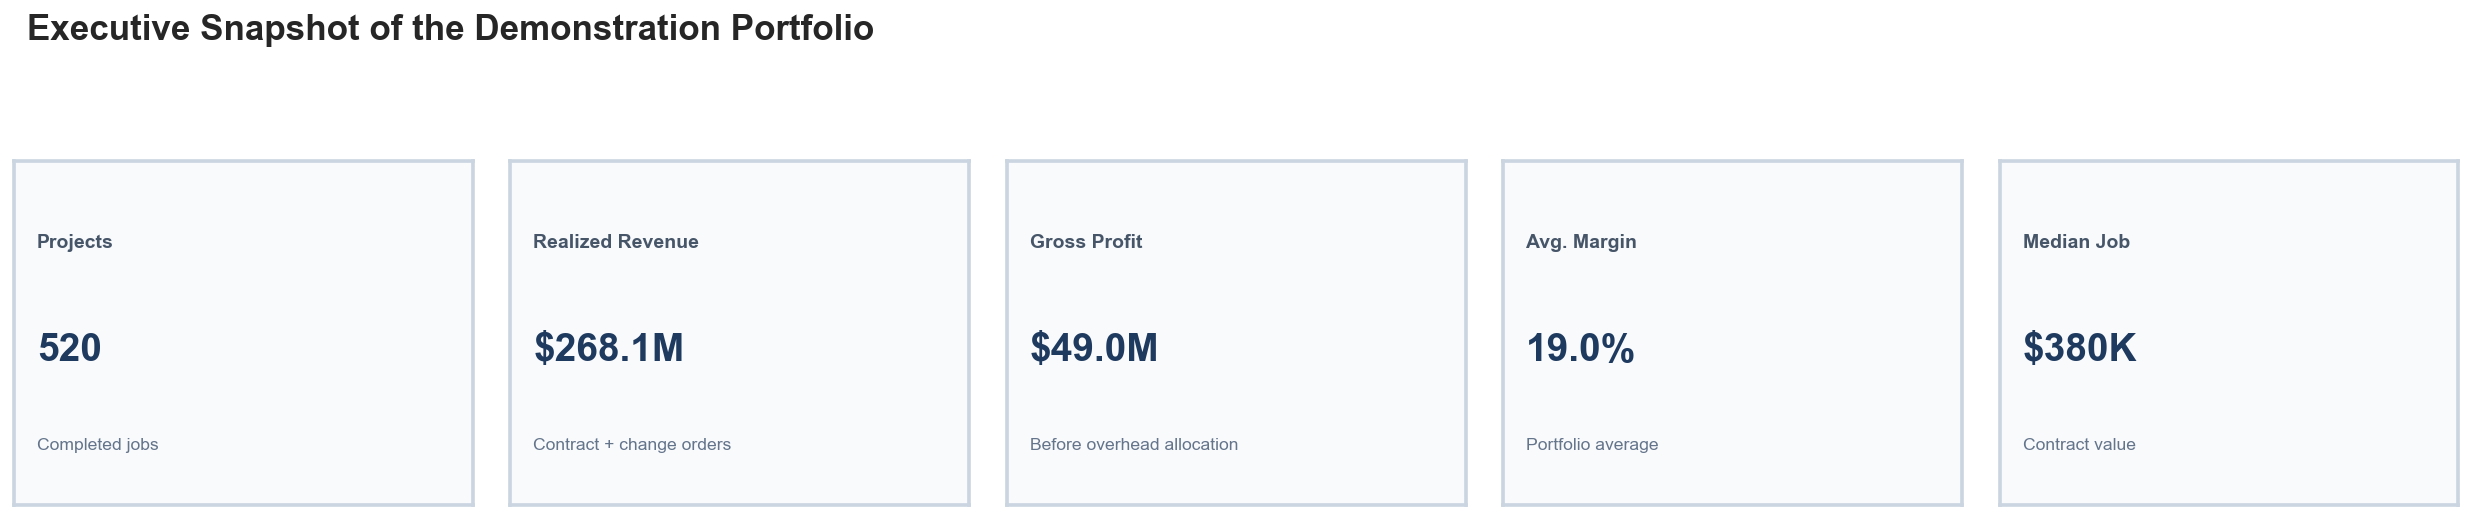

In [5]:
fig, axes = plt.subplots(1, 5, figsize=(18, 3.5))
kpis = [
    ("Projects", f"{len(df):,}", "Completed jobs"),
    ("Realized Revenue", dollars((df["contract_value"] + df["change_order_amount"]).sum()), "Contract + change orders"),
    ("Gross Profit", dollars(df["gross_profit"].sum()), "Before overhead allocation"),
    ("Avg. Margin", f"{df['profit_margin_pct'].mean():.1%}", "Portfolio average"),
    ("Median Job", dollars(df["contract_value"].median()), "Contract value"),
]
for ax, (title, value, subtitle) in zip(axes, kpis):
    ax.set_facecolor("#f8fafc")
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("#cbd5e1")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.text(0.05, 0.75, title, transform=ax.transAxes, fontsize=10, color="#475569", weight="bold")
    ax.text(0.05, 0.42, value, transform=ax.transAxes, fontsize=20, color=PALETTE["navy"], weight="bold")
    ax.text(0.05, 0.16, subtitle, transform=ax.transAxes, fontsize=9, color="#64748b")
fig.suptitle("Executive Snapshot of the Demonstration Portfolio", x=0.02, y=1.08, ha="left", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Exploratory Business Analysis

These first charts are meant to answer practical management questions before introducing regression. They show whether revenue is turning into gross profit, where the work is concentrated, and which job categories are worth a closer look.

### Are revenue and gross profit moving together over time?

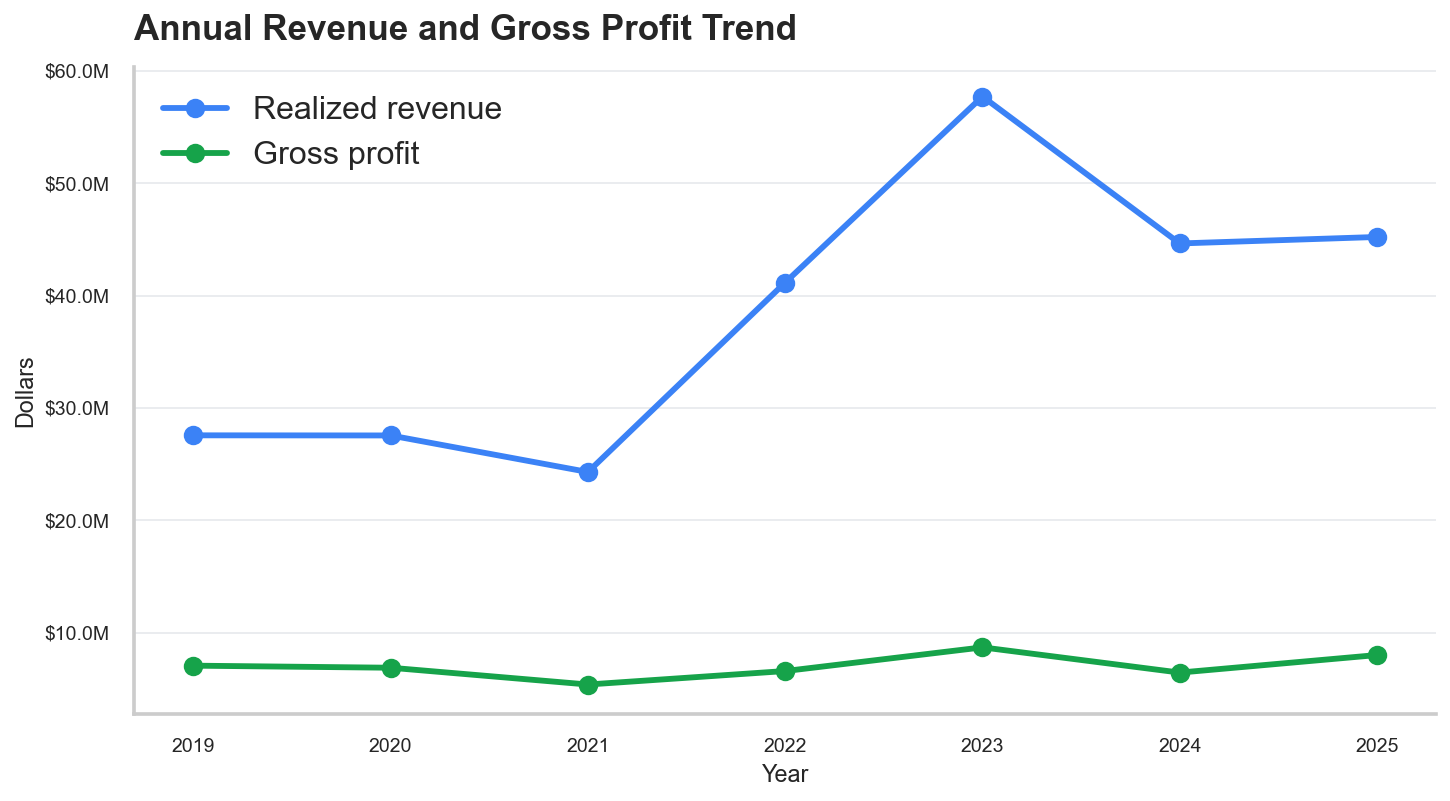

,year,realized_revenue,gross_profit,avg_margin,projects
0,2019,27558206.12,7061244.84,0.246886,69
1,2020,27546638.27,6877070.33,0.244984,67
2,2021,24293610.60,5383551.09,0.227137,46
3,2022,41156269.18,6583221.33,0.166965,74
4,2023,57707981.47,8690262.77,0.152392,92
5,2024,44632069.07,6445111.80,0.160979,85
6,2025,45209391.25,8006710.73,0.173449,87


In [6]:
annual = df.assign(realized_revenue=df["contract_value"] + df["change_order_amount"]).groupby("year", as_index=False).agg(
    realized_revenue=("realized_revenue", "sum"),
    gross_profit=("gross_profit", "sum"),
    avg_margin=("profit_margin_pct", "mean"),
    projects=("project_id", "count")
)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(annual["year"], annual["realized_revenue"], marker="o", linewidth=3, color=PALETTE["blue"], label="Realized revenue")
ax.plot(annual["year"], annual["gross_profit"], marker="o", linewidth=3, color=PALETTE["green"], label="Gross profit")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(dollars))
clean_axis(ax, "Annual Revenue and Gross Profit Trend", "Year", "Dollars")
ax.legend(frameon=False, loc="upper left")
plt.show()
display(annual)

This view separates growth from profitable growth. With real company data, I would use it to ask whether storm periods, expansion years, or high-volume years actually produced more gross profit.

### Which project types, roof materials, business types, and lead sources appear most attractive?

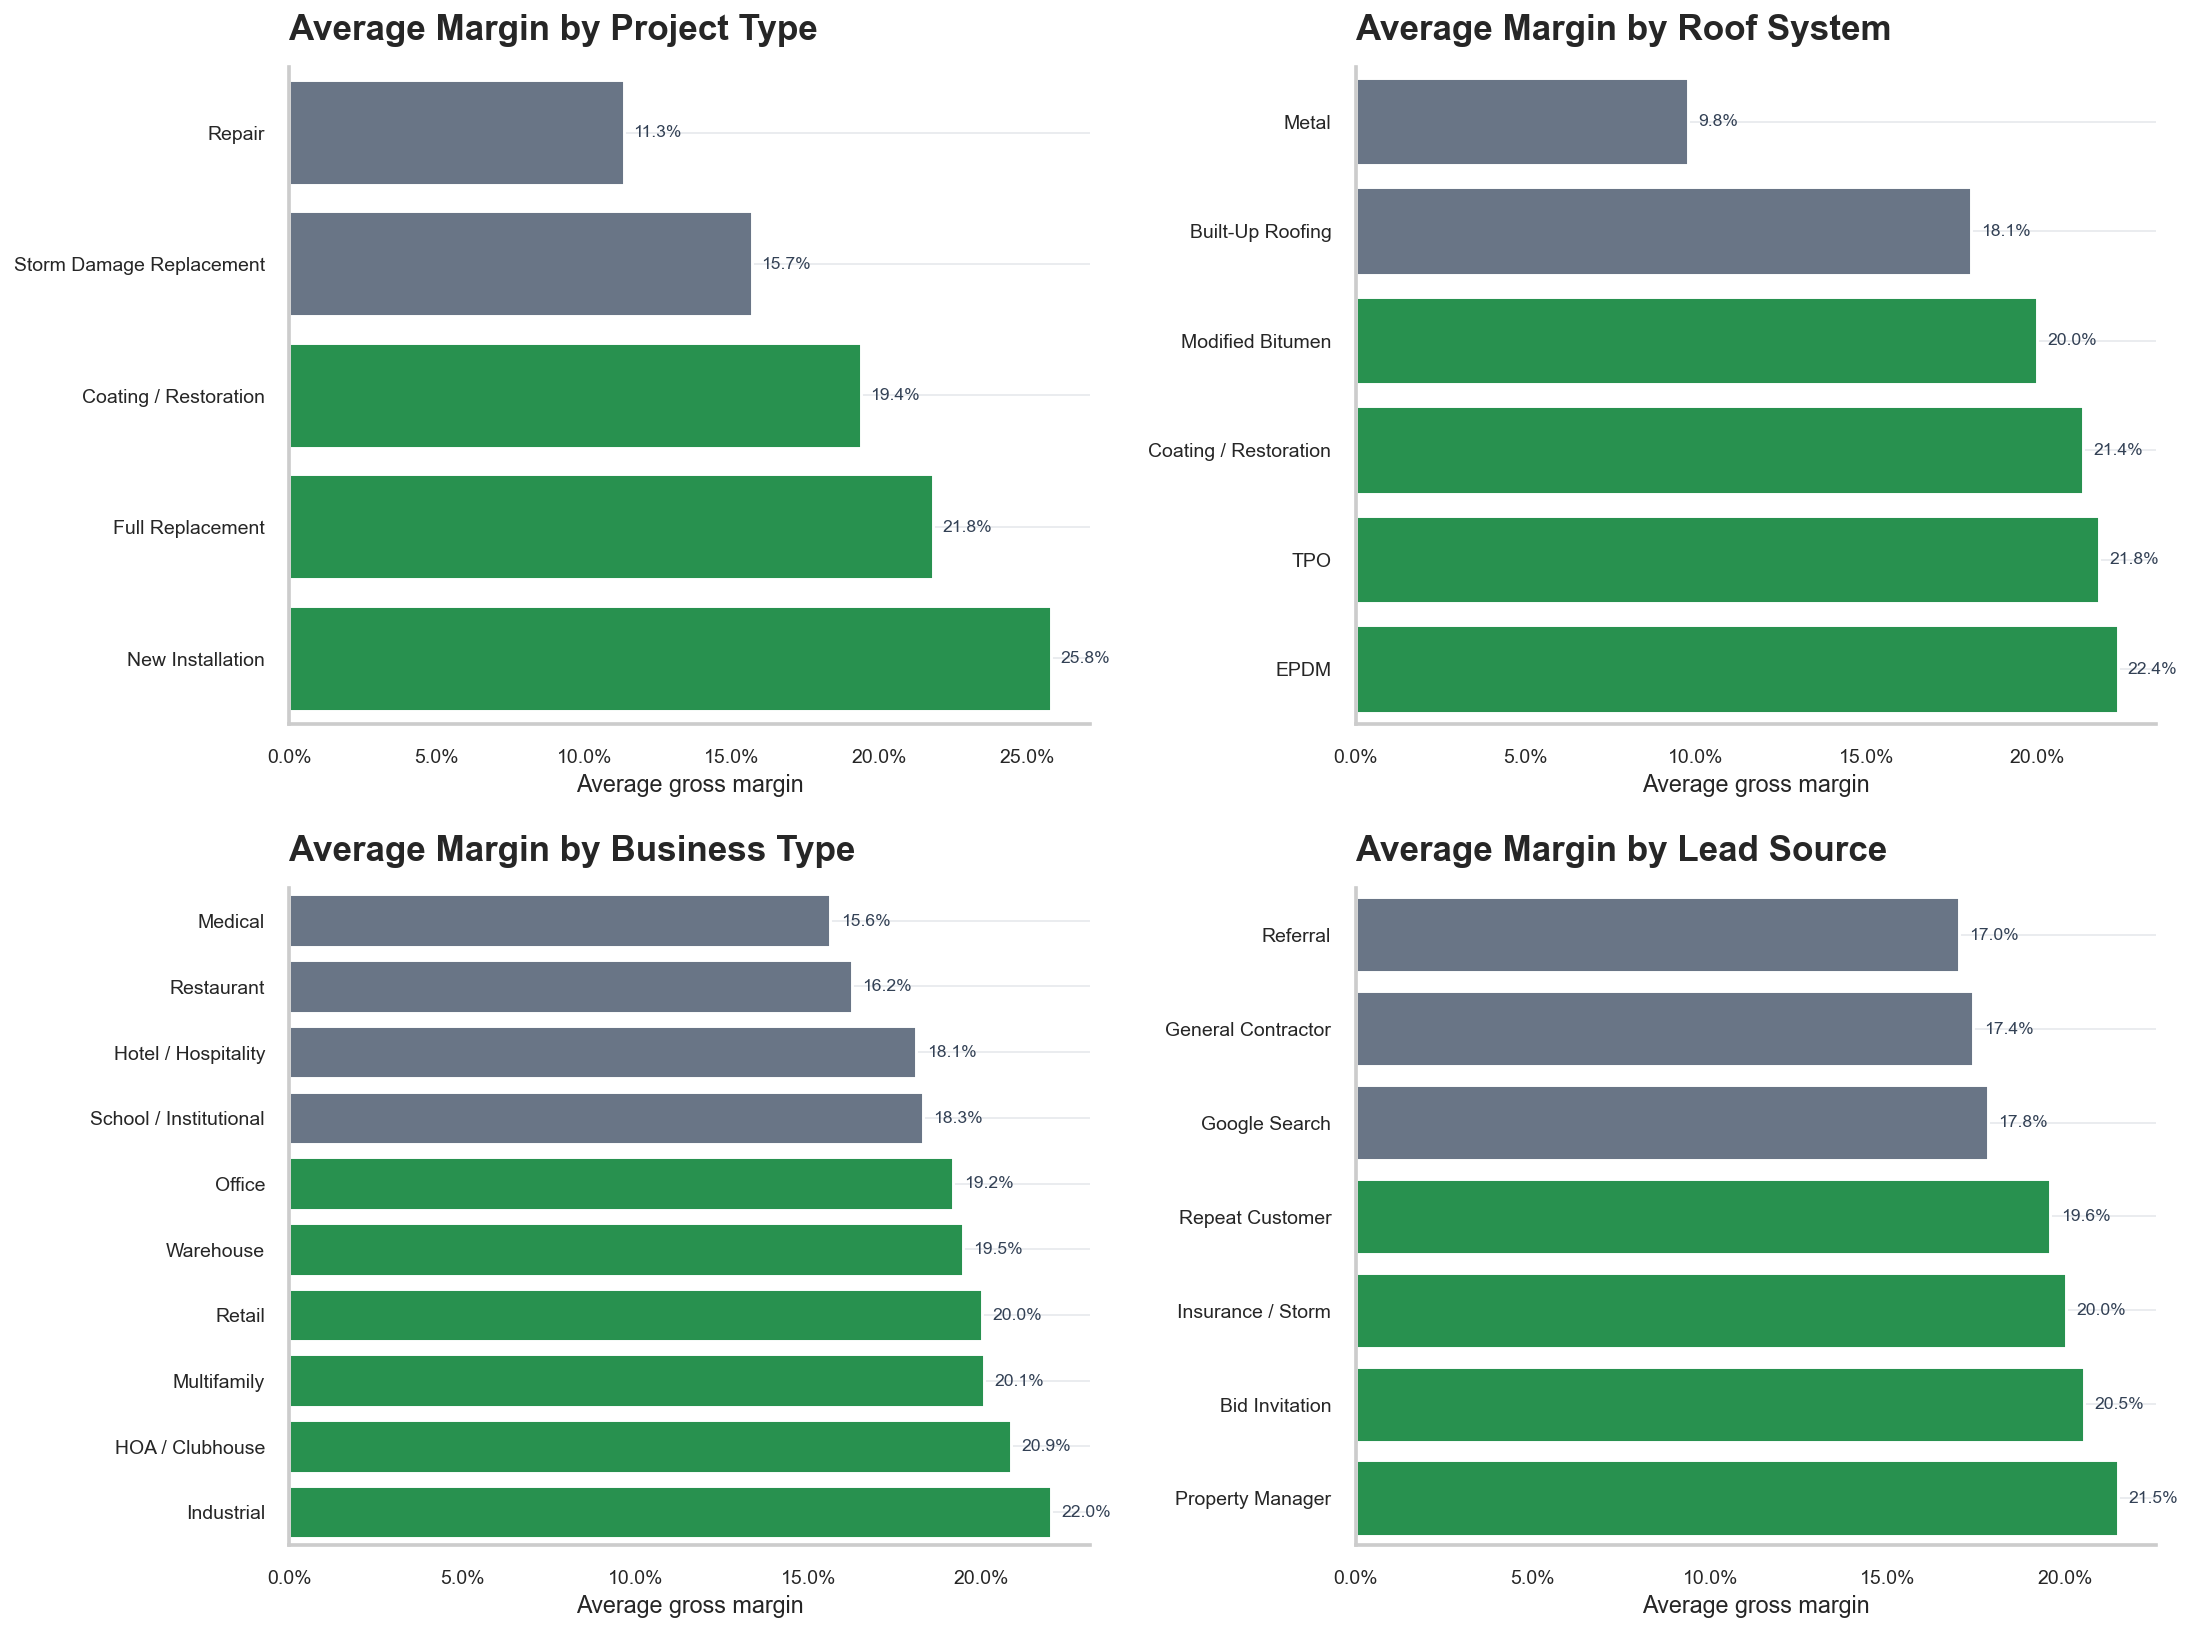

In [7]:
def margin_bar(category, title, ax):
    temp = df.groupby(category).agg(avg_margin=("profit_margin_pct", "mean"), projects=("project_id", "count")).sort_values("avg_margin")
    colors = [PALETTE["green"] if v >= df["profit_margin_pct"].mean() else PALETTE["gray"] for v in temp["avg_margin"]]
    sns.barplot(data=temp.reset_index(), y=category, x="avg_margin", ax=ax, palette=colors)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    clean_axis(ax, title, "Average gross margin", "")
    add_bar_labels(ax)
    for label, count in zip(ax.get_yticklabels(), temp["projects"]):
        label.set_text(f"{label.get_text()}  ({count})")
    ax.set_yticklabels([t.get_text() for t in ax.get_yticklabels()])

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
margin_bar("project_type", "Average Margin by Project Type", axes[0, 0])
margin_bar("roof_type", "Average Margin by Roof System", axes[0, 1])
margin_bar("business_type", "Average Margin by Business Type", axes[1, 0])
margin_bar("lead_source", "Average Margin by Lead Source", axes[1, 1])
plt.tight_layout()
plt.show()

These rankings are useful starting points, not final answers. Each category has a different mix of job size, complexity, location, and competitive pressure. The point is to see where the next question should be asked.

### Does bigger revenue automatically mean better margin?

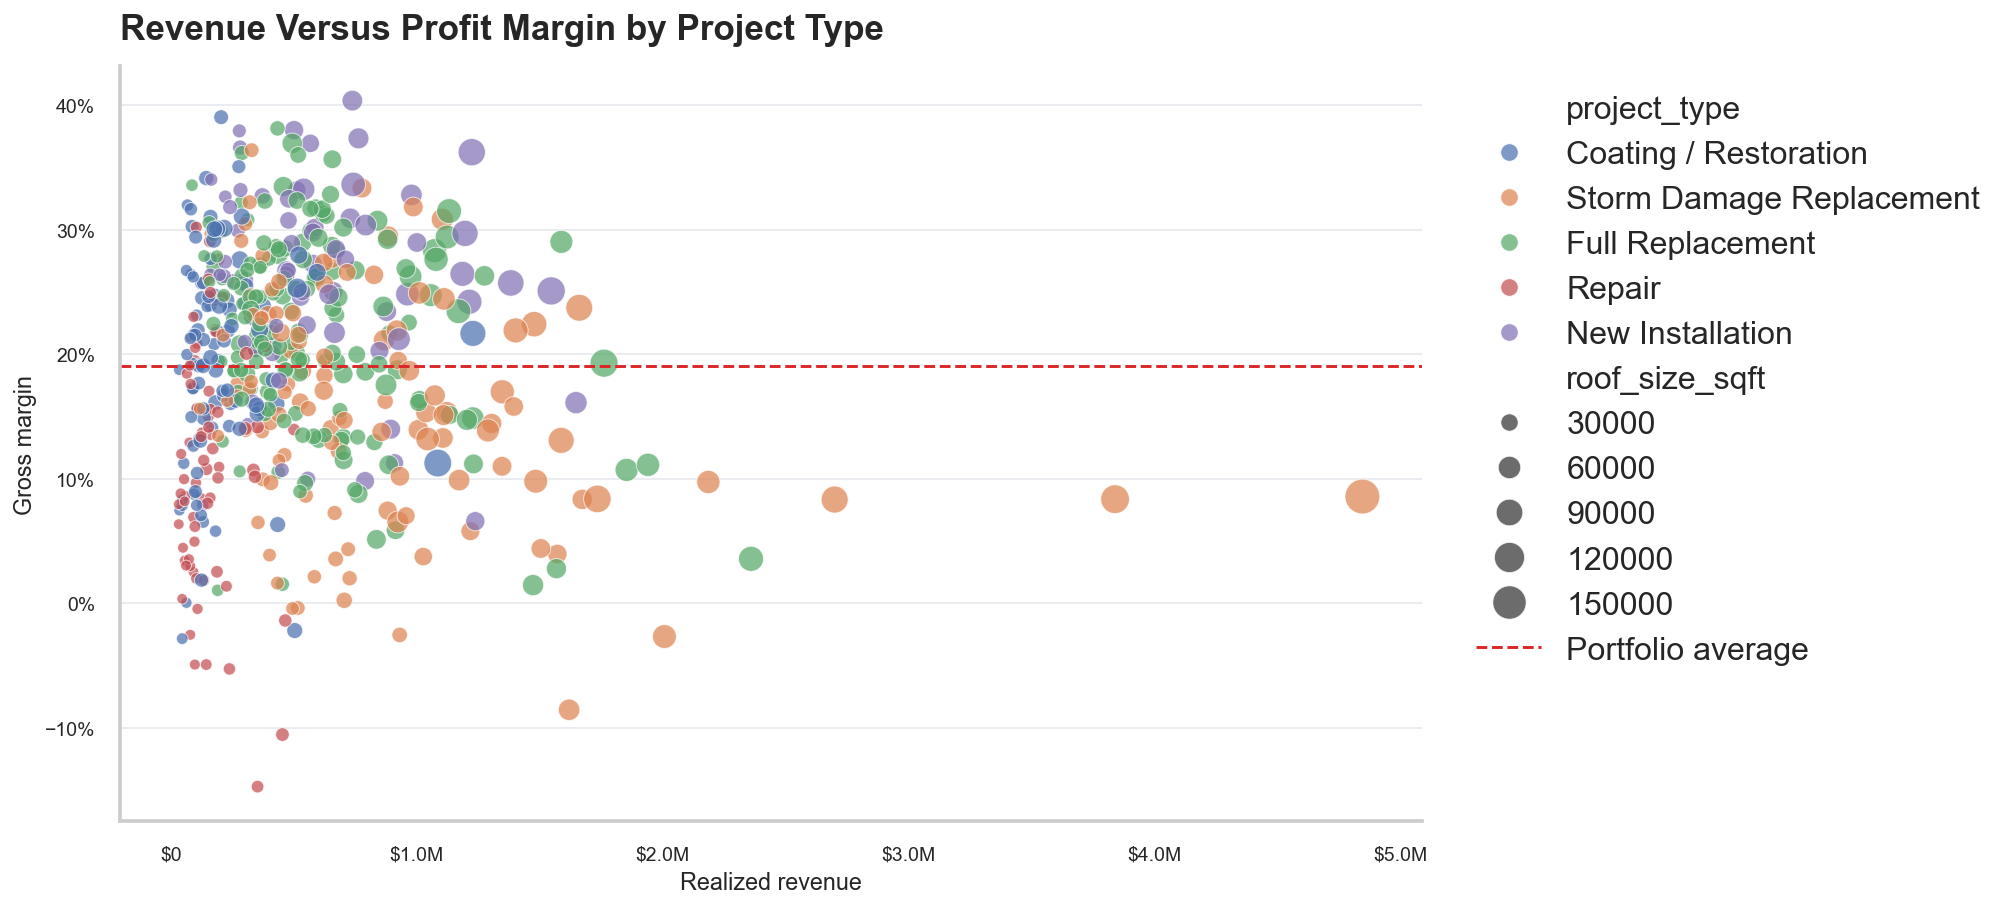

In [8]:
plot_df = df.assign(realized_revenue=df["contract_value"] + df["change_order_amount"])
fig, ax = plt.subplots(figsize=(12, 7))
sns.scatterplot(
    data=plot_df,
    x="realized_revenue",
    y="profit_margin_pct",
    hue="project_type",
    size="roof_size_sqft",
    sizes=(30, 320),
    alpha=0.72,
    ax=ax,
)
ax.axhline(df["profit_margin_pct"].mean(), color=PALETTE["red"], linestyle="--", linewidth=1.5, label="Portfolio average")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(dollars))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
clean_axis(ax, "Revenue Versus Profit Margin by Project Type", "Realized revenue", "Gross margin")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.show()

This view helps identify large jobs that did not earn enough margin and smaller jobs that may be more attractive than they first appear.

### Which locations combine volume and margin?

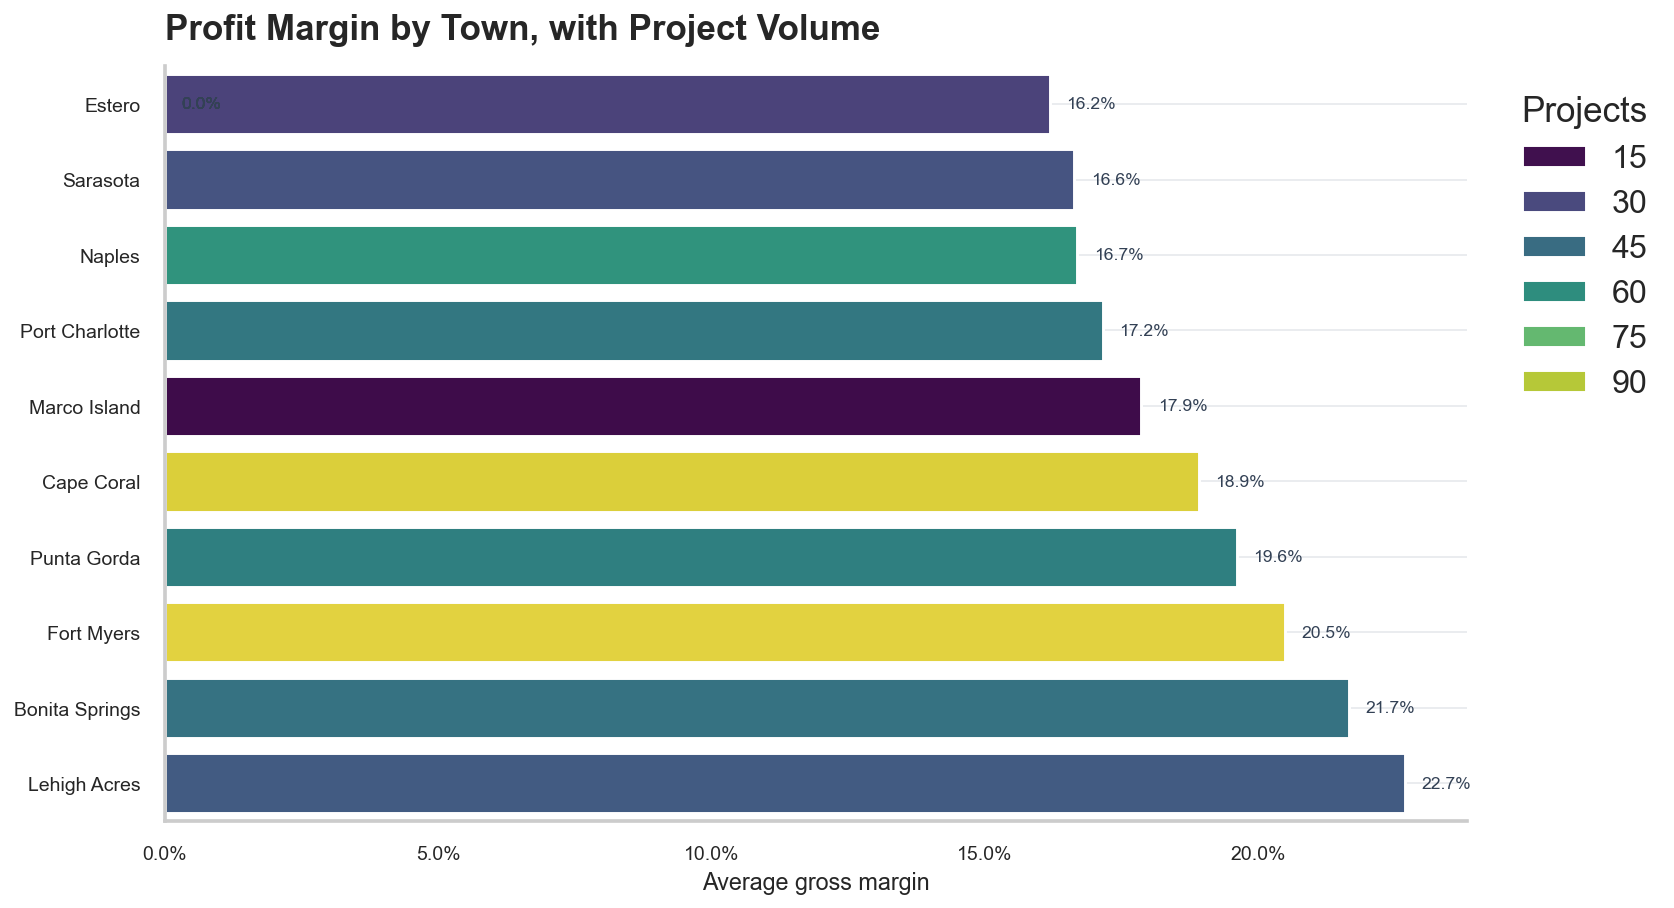

,town,avg_margin,projects,revenue
3,Fort Myers,0.204948,97,49667264.33
1,Cape Coral,0.189147,96,42799151.25
6,Naples,0.166935,62,37141760.24
8,Punta Gorda,0.196169,54,33244477.77
7,Port Charlotte,0.171606,50,25099888.64
0,Bonita Springs,0.216631,48,21497238.76
4,Lehigh Acres,0.226878,37,17282344.51
9,Sarasota,0.166403,34,15117462.83
2,Estero,0.161879,28,10012790.93
5,Marco Island,0.178679,14,6971233.05


In [9]:
town_summary = df.groupby("town", as_index=False).agg(
    avg_margin=("profit_margin_pct", "mean"),
    projects=("project_id", "count"),
    revenue=("contract_value", "sum")
).sort_values("avg_margin")

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(data=town_summary, y="town", x="avg_margin", hue="projects", dodge=False, palette="viridis", ax=ax)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
clean_axis(ax, "Profit Margin by Town, with Project Volume", "Average gross margin", "")
add_bar_labels(ax)
ax.legend(title="Projects", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()
display(town_summary.sort_values("projects", ascending=False))

This ranked location view is a simple substitute for a map. With real data, it could help evaluate service-area strategy, travel policies, and where business-development effort is paying off.

### Where do operational issues show up in margin?

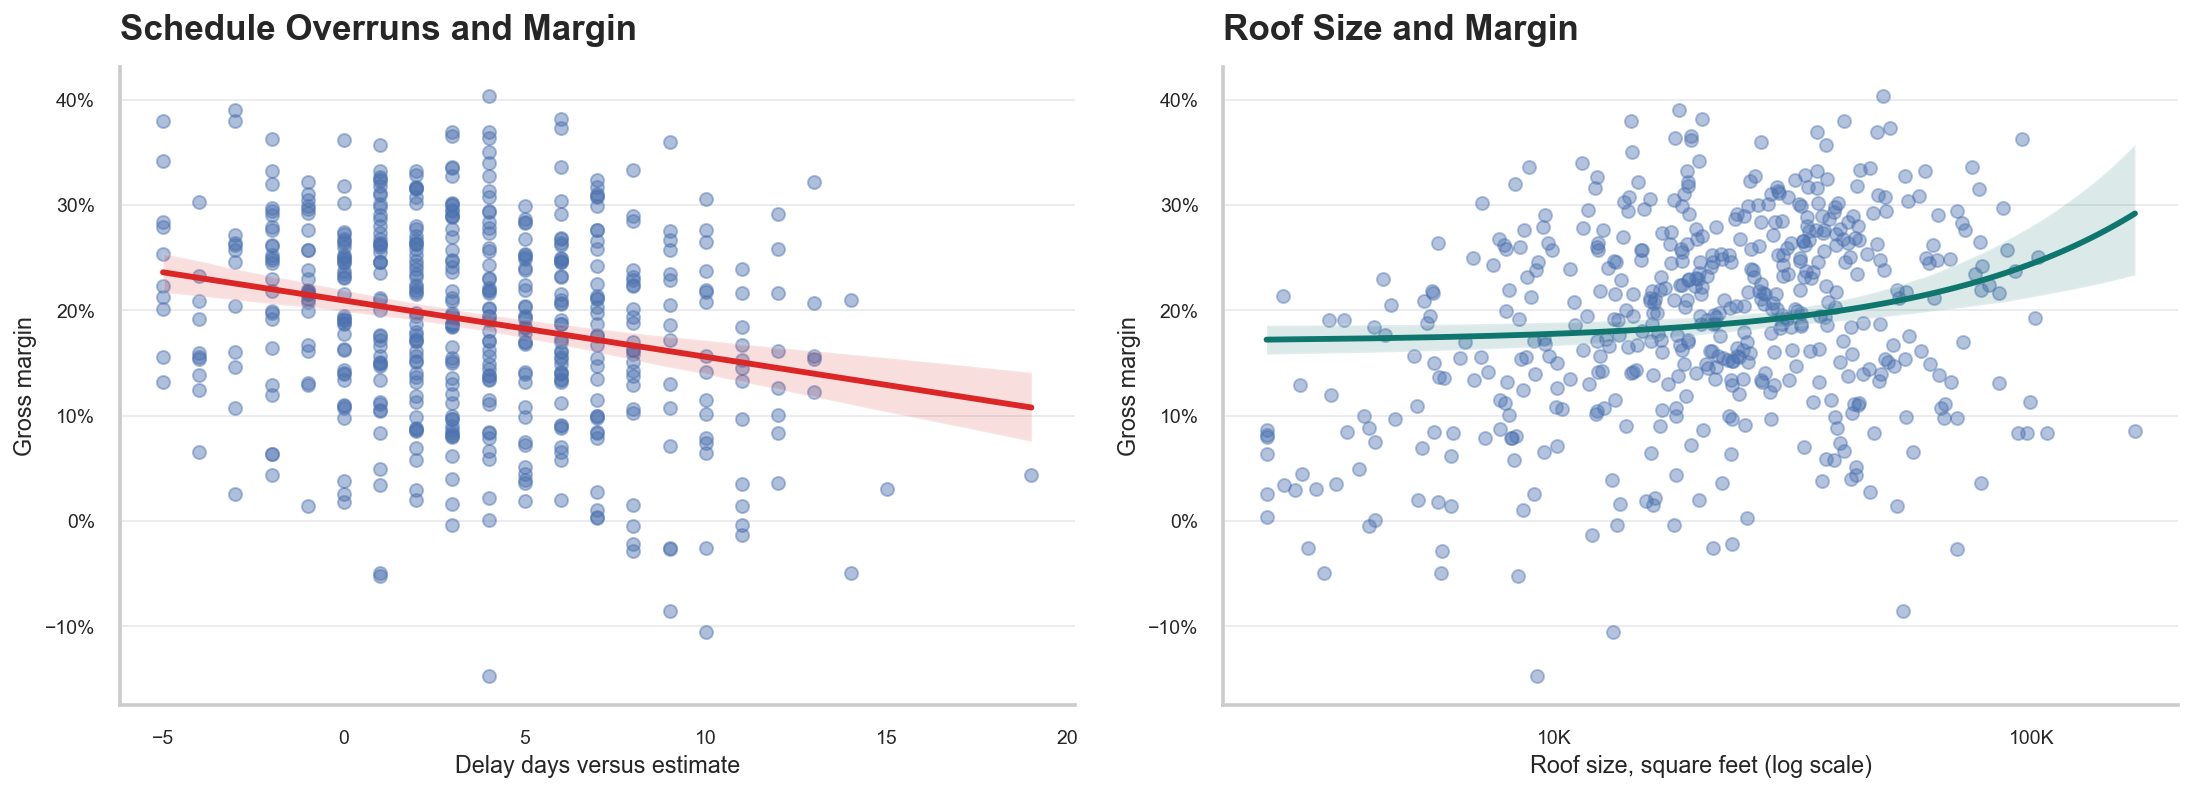

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.regplot(data=df, x="delay_days", y="profit_margin_pct", scatter_kws={"alpha": 0.45, "s": 45}, line_kws={"color": PALETTE["red"], "linewidth": 3}, ax=axes[0])
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
clean_axis(axes[0], "Schedule Overruns and Margin", "Delay days versus estimate", "Gross margin")

sns.regplot(data=df, x="roof_size_sqft", y="profit_margin_pct", scatter_kws={"alpha": 0.42, "s": 45}, line_kws={"color": PALETTE["teal"], "linewidth": 3}, ax=axes[1])
axes[1].set_xscale("log")
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f"{x/1000:.0f}K"))
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
clean_axis(axes[1], "Roof Size and Margin", "Roof size, square feet (log scale)", "Gross margin")
plt.tight_layout()
plt.show()

These charts help separate pricing issues from execution issues. Low margin may come from the way the job was sold, the way it was scoped, the way it was run, or some combination of all three.

### How different is hurricane-related work?

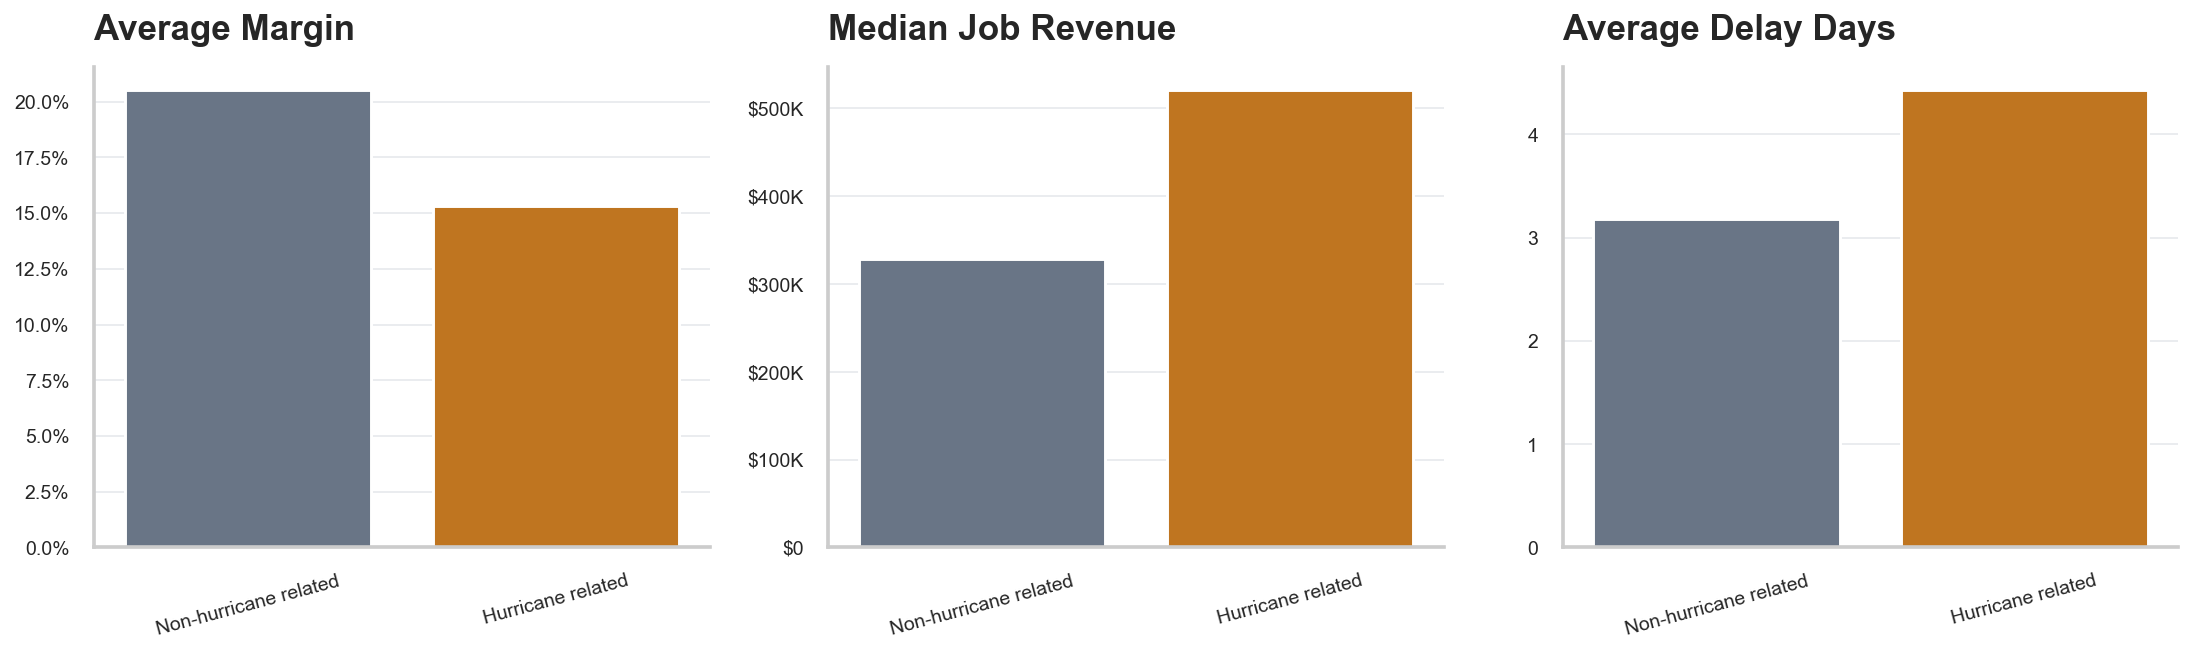

,hurricane_related_flag,projects,avg_margin,median_revenue,avg_delay,avg_labor_tightness
0,Non-hurricane related,372,0.205357,328363.53,3.180108,108.731183
1,Hurricane related,148,0.153063,521126.61,4.432432,113.000000


In [11]:
hurr = df.assign(realized_revenue=df["contract_value"] + df["change_order_amount"]).groupby("hurricane_related_flag", as_index=False).agg(
    projects=("project_id", "count"),
    avg_margin=("profit_margin_pct", "mean"),
    median_revenue=("realized_revenue", "median"),
    avg_delay=("delay_days", "mean"),
    avg_labor_tightness=("labor_tightness_index", "mean")
)
hurr["hurricane_related_flag"] = hurr["hurricane_related_flag"].map({False: "Non-hurricane related", True: "Hurricane related"})

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.barplot(data=hurr, x="hurricane_related_flag", y="avg_margin", ax=axes[0], palette=[PALETTE["gray"], PALETTE["gold"]])
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
clean_axis(axes[0], "Average Margin", "", "")
sns.barplot(data=hurr, x="hurricane_related_flag", y="median_revenue", ax=axes[1], palette=[PALETTE["gray"], PALETTE["gold"]])
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(dollars))
clean_axis(axes[1], "Median Job Revenue", "", "")
sns.barplot(data=hurr, x="hurricane_related_flag", y="avg_delay", ax=axes[2], palette=[PALETTE["gray"], PALETTE["gold"]])
clean_axis(axes[2], "Average Delay Days", "", "")
for ax in axes:
    ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()
display(hurr)

Storm-driven work can bring pricing power and operational strain at the same time. With actual company data, the key question would be whether the extra revenue premium is enough to offset labor pressure, material exposure, delays, and subcontractor dependence.

### Which project-type and material combinations look strongest?

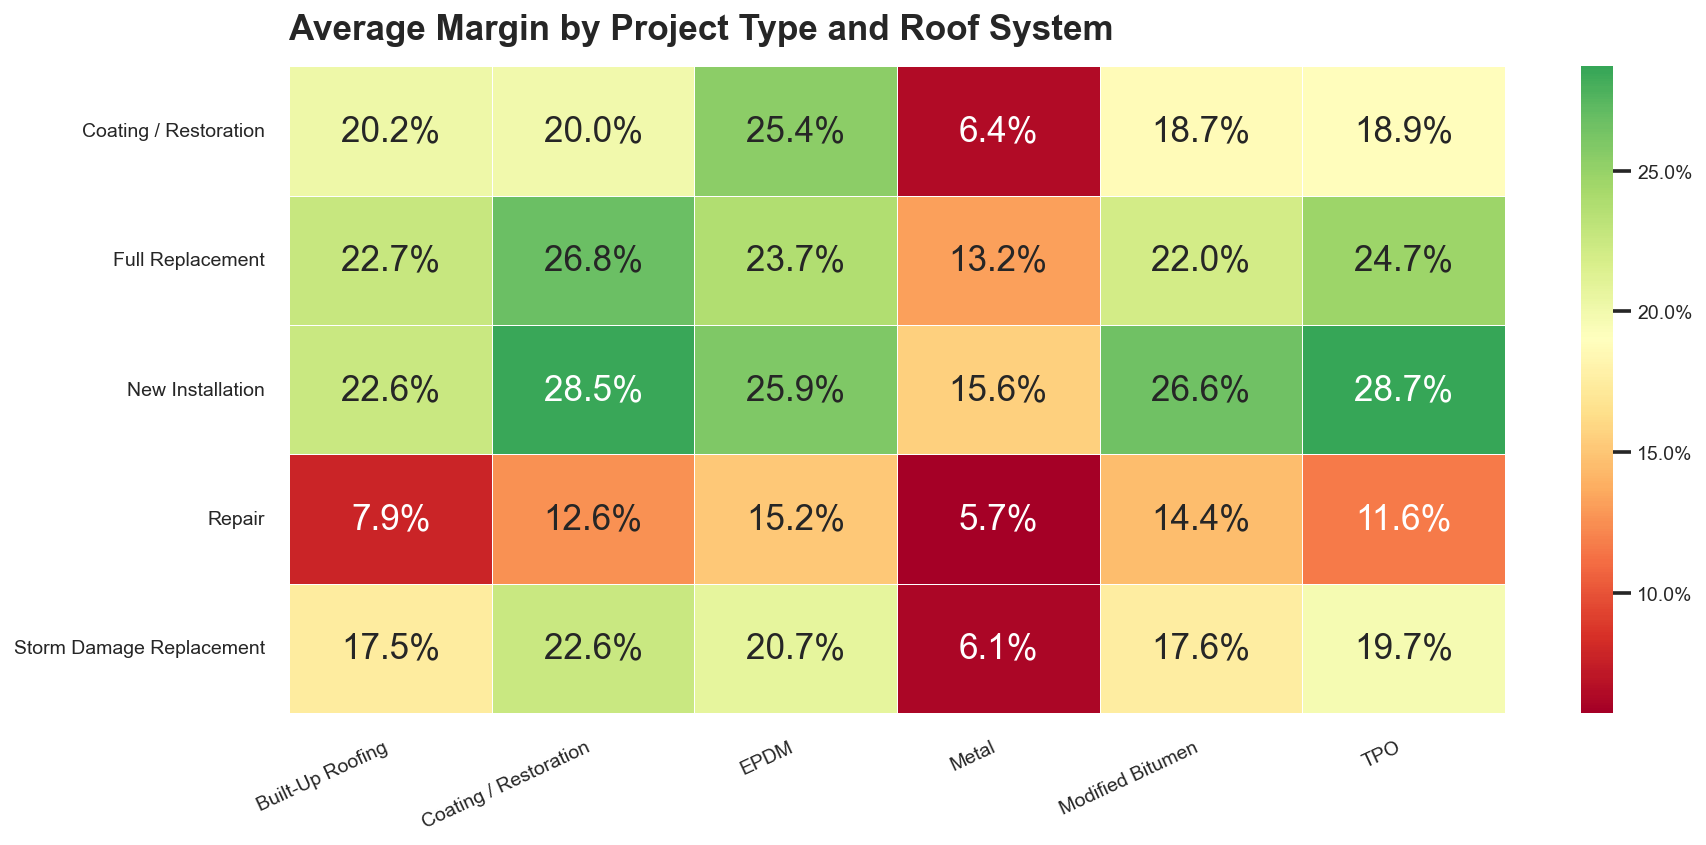

In [12]:
matrix = df.pivot_table(index="project_type", columns="roof_type", values="profit_margin_pct", aggfunc="mean")
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(matrix, annot=True, fmt=".1%", cmap="RdYlGn", center=df["profit_margin_pct"].mean(), linewidths=0.5, cbar_kws={"format": mtick.PercentFormatter(1.0)}, ax=ax)
clean_axis(ax, "Average Margin by Project Type and Roof System", "", "")
plt.xticks(rotation=25, ha="right")
plt.yticks(rotation=0)
plt.show()

This matrix is useful for portfolio strategy. It highlights combinations that may deserve more aggressive pursuit, tighter estimating review, or different production planning.

## 5. Explain Regression in Business Terms

Simple averages can be misleading because jobs are not directly comparable. For example, metal projects might appear more profitable partly because they are larger, located in different markets, sold through different channels, or completed during different demand conditions.

Regression is a way to compare jobs more fairly. In plain English, it asks: when two jobs are similar on the other factors in the model, how is this one factor associated with margin?

The important word is **associated**. Regression does not prove cause and effect by itself. It is a structured way to learn from historical patterns and decide where management should look more closely.

In [13]:
df["has_overrun"] = df["delay_days"] > 0
simple_overrun = df.groupby("has_overrun").agg(
    projects=("project_id", "count"),
    avg_margin=("profit_margin_pct", "mean"),
    median_margin=("profit_margin_pct", "median"),
    avg_contract=("contract_value", "mean"),
).rename(index={False: "No schedule overrun", True: "Schedule overrun"})
simple_overrun

,projects,avg_margin,median_margin,avg_contract
has_overrun,,,,
No schedule overrun,121,0.213465,0.2196,486255.518430
Schedule overrun,399,0.183501,0.1874,501244.848571


The simple comparison above is helpful, but it does not prove that schedule overruns alone explain the margin difference. Harder jobs may both overrun and have lower margins for reasons that were visible before the job started. That is why the next section controls for job mix.

## 6. Prepare the Regression Dataset

The outcome variable is `profit_margin_pct`. I split the predictors into two models:

**Model 1: Estimating-stage model** uses information that should generally be known before the company accepts or prices the job. This version is useful for bid review, pricing discipline, and deciding which jobs to pursue.

**Model 2: Post-job operational performance model** adds items that are known during or after the job, such as delays and change orders. This version is more useful for post-job reviews and operational improvement.

Categorical variables such as roof type, project type, and town are converted into comparison groups. I also avoid loading the model with too many overlapping variables. For example, roof size and contract value are closely related, so the model uses log roof size rather than trying to interpret both at the same time.

In [14]:
reg = df.copy()
reg["margin"] = reg["profit_margin_pct"]
reg["log_roof_size"] = np.log(reg["roof_size_sqft"])
reg["change_order_pct"] = reg["change_order_amount"] / reg["contract_value"]
reg["duration_overrun_pct"] = (reg["actual_duration_days"] - reg["estimated_duration_days"]) / reg["estimated_duration_days"]

bool_cols = [
    "occupied_building_flag", "tear_off_required_flag", "hurricane_related_flag",
    "post_hurricane_demand_flag", "competitive_bid_flag", "won_with_discount_flag",
    "emergency_job_flag"
]
for col in bool_cols:
    reg[col] = reg[col].astype(int)

model1_formula = '''
margin ~ log_roof_size
    + C(project_type)
    + C(roof_type)
    + C(business_type)
    + C(town)
    + C(lead_source)
    + C(customer_type)
    + C(roof_access_complexity)
    + occupied_building_flag
    + tear_off_required_flag
    + hurricane_related_flag
    + post_hurricane_demand_flag
    + competitive_bid_flag
    + discount_pct
    + distance_from_home_base_miles
    + permit_complexity_score
'''

model2_formula = model1_formula + '''
    + delay_days
    + weather_delay_days
    + duration_overrun_pct
    + change_order_pct
    + material_price_index
    + labor_tightness_index
    + emergency_job_flag
'''

model1 = smf.ols(model1_formula, data=reg).fit(cov_type="HC3")
model2 = smf.ols(model2_formula, data=reg).fit(cov_type="HC3")

model_stats = pd.DataFrame({
    "Model": ["Model 1: Estimating-stage", "Model 2: Post-job operational"],
    "R-squared": [model1.rsquared, model2.rsquared],
    "Adjusted R-squared": [model1.rsquared_adj, model2.rsquared_adj],
    "Mean absolute error": [
        mean_absolute_error(reg["margin"], model1.predict(reg)),
        mean_absolute_error(reg["margin"], model2.predict(reg)),
    ],
})
model_stats

,Model,R-squared,Adjusted R-squared,Mean absolute error
0,Model 1: Estimating-stage,0.629615,0.594451,0.045930
1,Model 2: Post-job operational,0.830755,0.811910,0.030176


## 7. Run Regression Models

The tables below translate the regression output into percentage-point margin impacts. For a numeric variable, the coefficient is the estimated change in gross margin for a one-unit increase in that variable. For a category, it is the estimated difference from the reference category, holding the other observed factors constant.

P-values are included as a rough signal of how much statistical noise may be present. I would not treat them as a mechanical business decision rule.

In [15]:
def coefficient_table(model, top_n=18):
    table = pd.DataFrame({
        "term": model.params.index,
        "coef": model.params.values,
        "p_value": model.pvalues.values,
        "conf_low": model.conf_int()[0].values,
        "conf_high": model.conf_int()[1].values,
    })
    table = table[table["term"] != "Intercept"].copy()
    table["margin_impact_points"] = table["coef"] * 100
    table["statistical_signal"] = np.select(
        [table["p_value"] < 0.01, table["p_value"] < 0.05, table["p_value"] < 0.10],
        ["Strong", "Moderate", "Directional"],
        default="Weak / noisy"
    )
    table["business_label"] = (
        table["term"]
        .str.replace("C(", "", regex=False)
        .str.replace(")[T.", ": ", regex=False)
        .str.replace("]", "", regex=False)
        .str.replace("_", " ", regex=False)
    )
    return table.sort_values("margin_impact_points")


coef1 = coefficient_table(model1)
coef2 = coefficient_table(model2)

display(model_stats.style.format({"R-squared": "{:.2f}", "Adjusted R-squared": "{:.2f}", "Mean absolute error": "{:.1%}"}))
display(coef1.reindex(coef1["margin_impact_points"].abs().sort_values(ascending=False).index).head(20)[["business_label", "margin_impact_points", "p_value", "statistical_signal"]].style.format({"margin_impact_points": "{:+.1f}", "p_value": "{:.3f}"}))
display(coef2.reindex(coef2["margin_impact_points"].abs().sort_values(ascending=False).index).head(20)[["business_label", "margin_impact_points", "p_value", "statistical_signal"]].style.format({"margin_impact_points": "{:+.1f}", "p_value": "{:.3f}"}))

,Model,R-squared,Adjusted R-squared,Mean absolute error
0,Model 1: Estimating-stage,0.63,0.59,4.6%
1,Model 2: Post-job operational,0.83,0.81,3.0%


,business_label,margin_impact_points,p_value,statistical_signal
7,roof type: Metal,-9.1,0.000,Strong
35,roof access complexity: Low,+8.3,0.000,Strong
2,project type: New Installation,+6.9,0.000,Strong
36,roof access complexity: Medium,+6.5,0.000,Strong
1,project type: Full Replacement,+5.9,0.000,Strong
41,post hurricane demand flag,-5.5,0.000,Strong
6,roof type: EPDM,+4.9,0.000,Strong
3,project type: Repair,-3.9,0.005,Strong
5,roof type: Coating / Restoration,+3.8,0.004,Strong
20,town: Estero,-2.7,0.117,Weak / noisy


,business_label,margin_impact_points,p_value,statistical_signal
49,change order pct,+71.3,0.000,Strong
43,discount pct,-18.9,0.010,Moderate
7,roof type: Metal,-7.2,0.000,Strong
2,project type: New Installation,+7.0,0.000,Strong
35,roof access complexity: Low,+6.0,0.000,Strong
5,roof type: Coating / Restoration,+5.0,0.000,Strong
1,project type: Full Replacement,+4.9,0.000,Strong
36,roof access complexity: Medium,+4.1,0.000,Strong
6,roof type: EPDM,+4.0,0.000,Strong
3,project type: Repair,-3.8,0.000,Strong


**How I would use the two models:**

Model 1 is the more useful version before a price is submitted. It can support bid reviews, minimum-margin thresholds, complexity premiums, discount discipline, and pursuit decisions.

Model 2 is more useful after the job is complete. By adding execution variables, it helps show where margin leakage may have come from: schedule overruns, weather exposure, labor tightness, material escalation, change-order discipline, or other operating issues.

## 8. Visualization of Regression Results

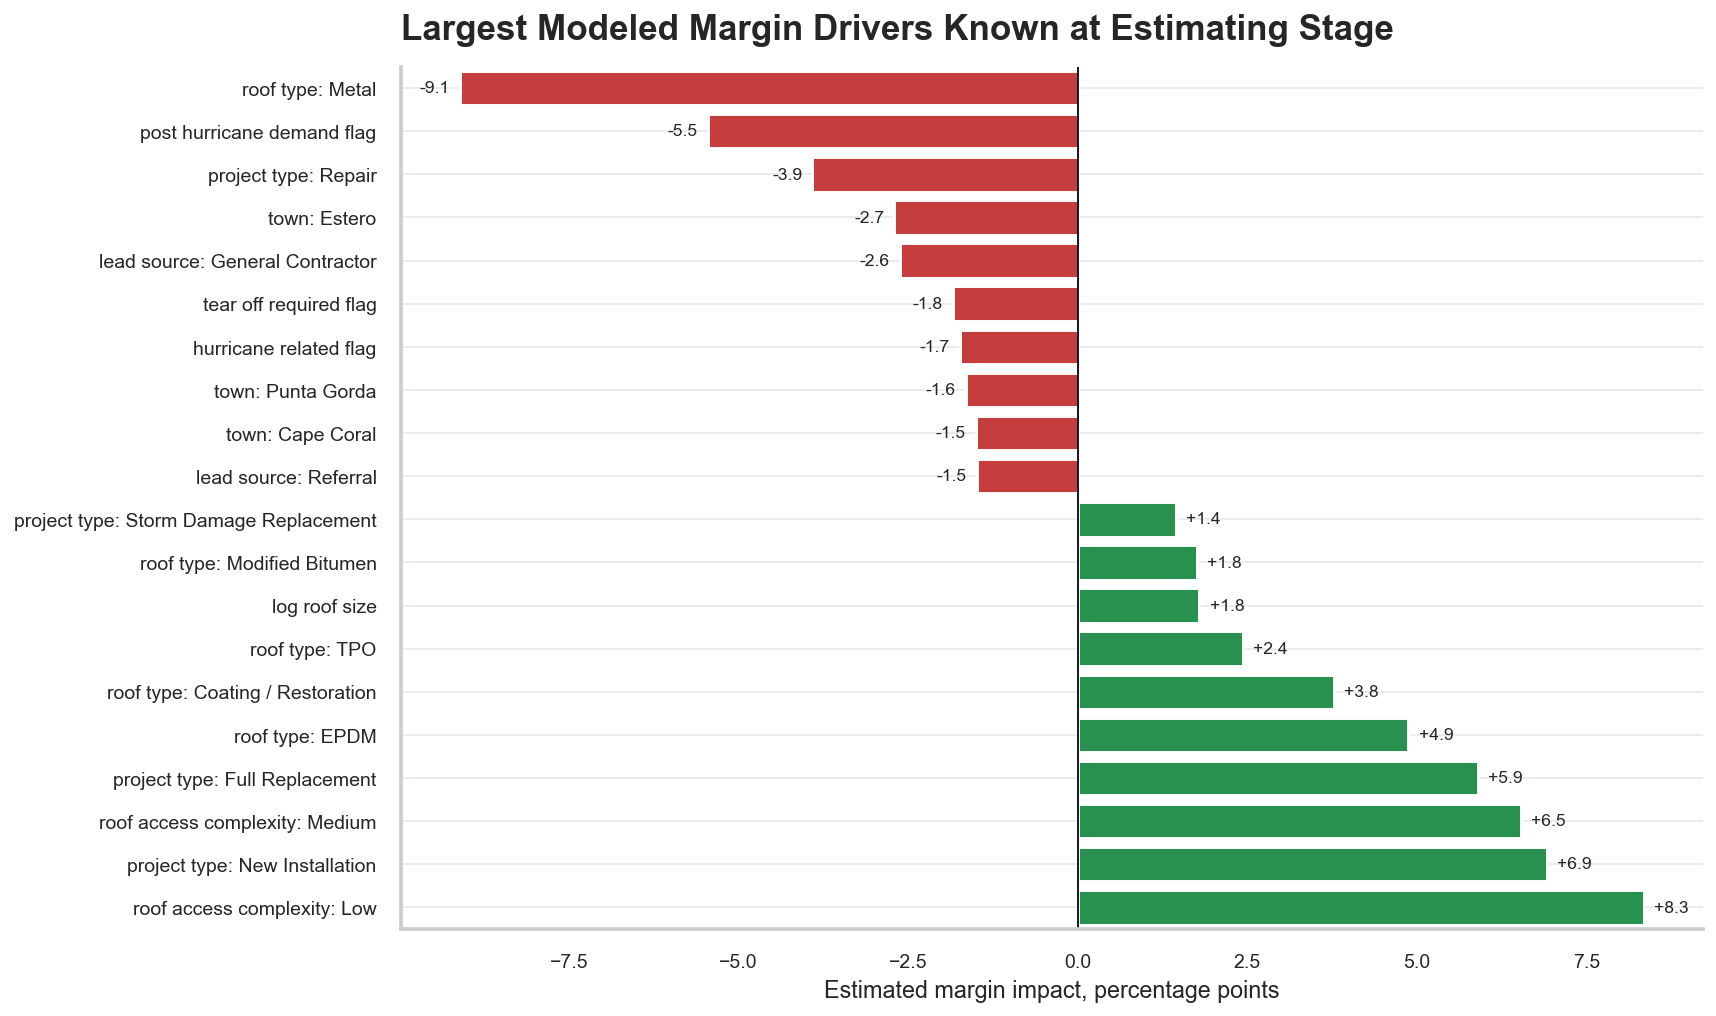

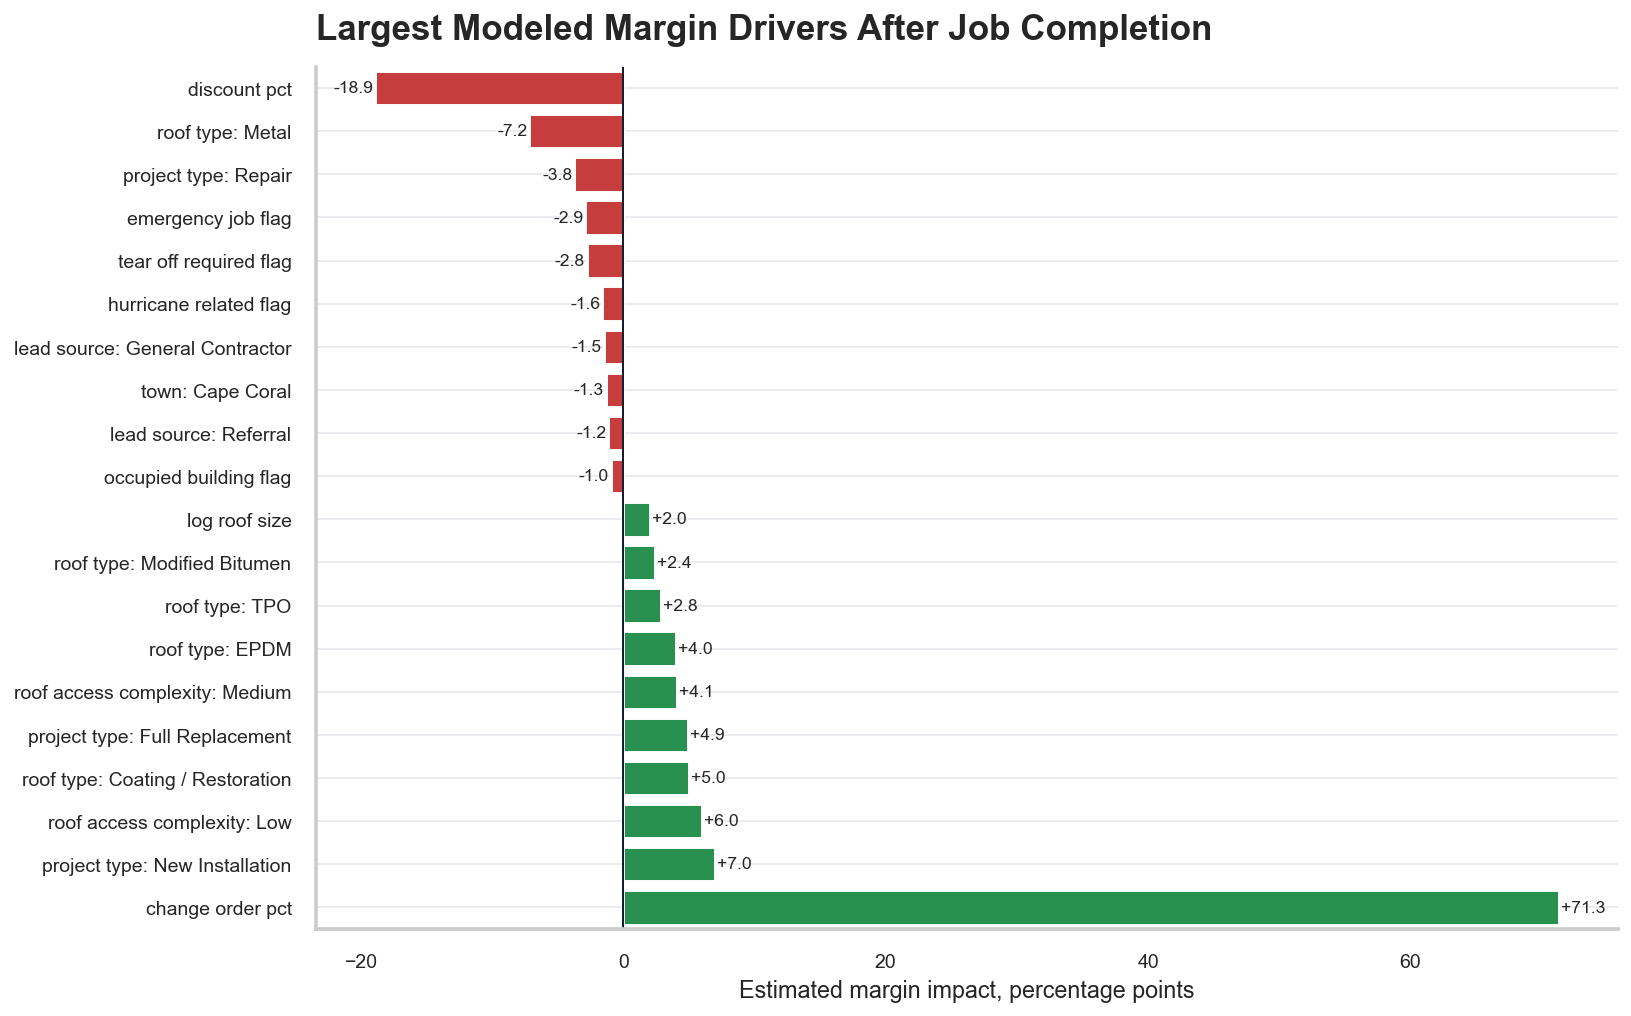

In [16]:
def plot_driver_bars(coef_table, title, n_each=10):
    drivers = pd.concat([coef_table.head(n_each), coef_table.tail(n_each)]).copy()
    drivers = drivers.sort_values("margin_impact_points")
    fig, ax = plt.subplots(figsize=(12, 8))
    colors = np.where(drivers["margin_impact_points"] >= 0, PALETTE["green"], PALETTE["red"])
    sns.barplot(data=drivers, y="business_label", x="margin_impact_points", palette=colors, ax=ax)
    ax.axvline(0, color="#0f172a", linewidth=1)
    clean_axis(ax, title, "Estimated margin impact, percentage points", "")
    for patch in ax.patches:
        width = patch.get_width()
        ax.text(width + (0.15 if width >= 0 else -0.15), patch.get_y() + patch.get_height()/2, f"{width:+.1f}", va="center", ha="left" if width >= 0 else "right", fontsize=9)
    plt.show()

plot_driver_bars(coef1, "Largest Modeled Margin Drivers Known at Estimating Stage")
plot_driver_bars(coef2, "Largest Modeled Margin Drivers After Job Completion")

These driver charts make the regression easier to discuss without walking through a full statistical output table. They show which modeled factors are most associated with higher or lower margin.

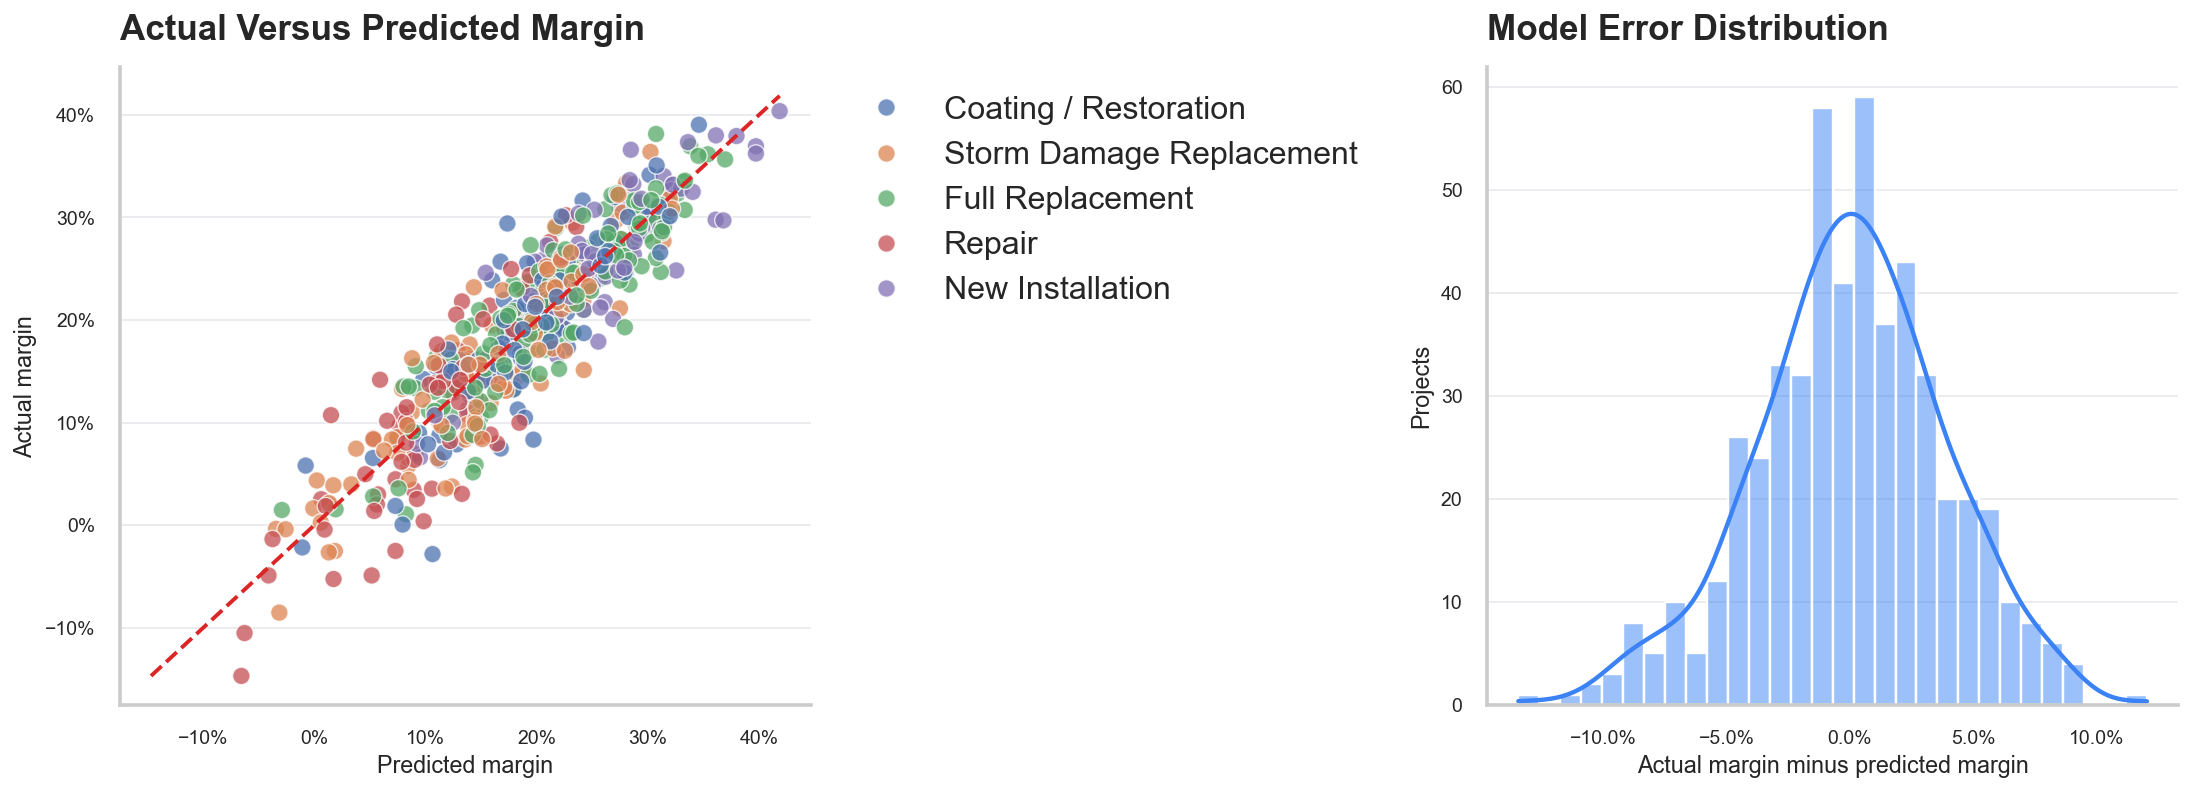

In [17]:
reg["predicted_margin_model2"] = model2.predict(reg)
reg["residual_model2"] = reg["margin"] - reg["predicted_margin_model2"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(data=reg, x="predicted_margin_model2", y="margin", hue="project_type", alpha=0.75, ax=axes[0])
lims = [min(reg["predicted_margin_model2"].min(), reg["margin"].min()), max(reg["predicted_margin_model2"].max(), reg["margin"].max())]
axes[0].plot(lims, lims, color=PALETTE["red"], linestyle="--", linewidth=2)
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
clean_axis(axes[0], "Actual Versus Predicted Margin", "Predicted margin", "Actual margin")
axes[0].legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")

sns.histplot(reg["residual_model2"], bins=30, kde=True, color=PALETTE["blue"], ax=axes[1])
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
clean_axis(axes[1], "Model Error Distribution", "Actual margin minus predicted margin", "Projects")
plt.tight_layout()
plt.show()

The actual-versus-predicted chart shows whether the model is broadly calibrated. The error distribution shows how much variation is still unexplained, which is normal in job-costing data.

### Scenario Comparison

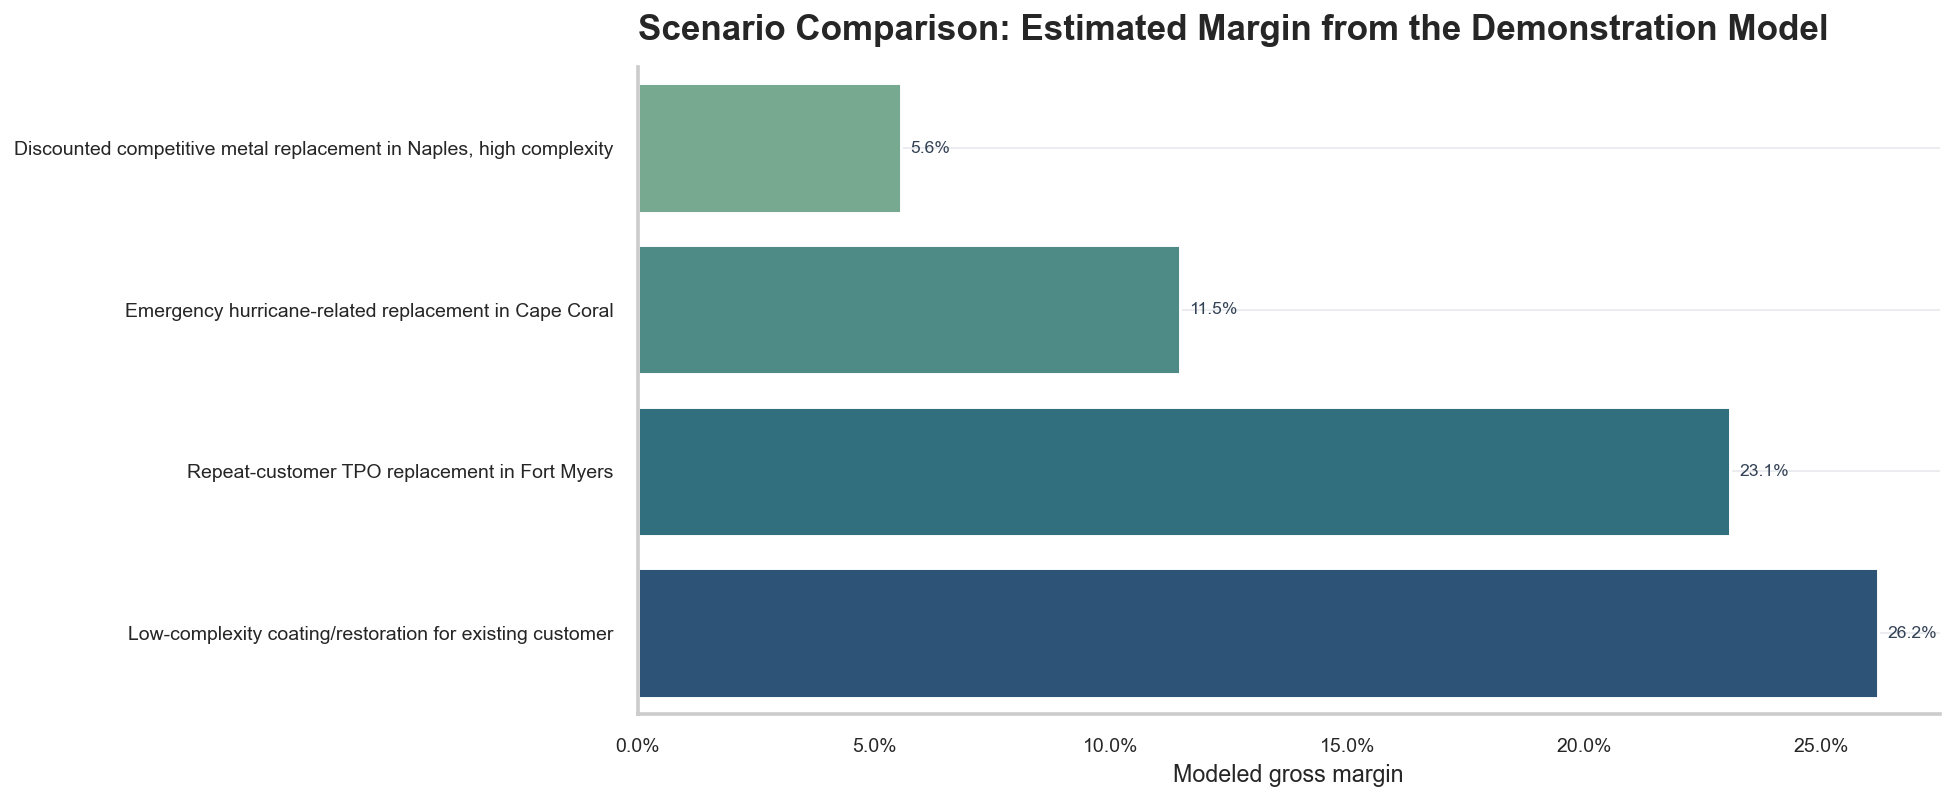

,Scenario,Estimated margin
0,Repeat-customer TPO replacement in Fort Myers,23.1%
1,"Discounted competitive metal replacement in Naples, high complexity",5.6%
2,Emergency hurricane-related replacement in Cape Coral,11.5%
3,Low-complexity coating/restoration for existing customer,26.2%


In [18]:
def predict_margin_scenario(**kwargs):
    defaults = {
        "roof_size_sqft": 35000,
        "project_type": "Full Replacement",
        "roof_type": "TPO",
        "business_type": "Retail",
        "town": "Fort Myers",
        "lead_source": "Referral",
        "customer_type": "Existing",
        "roof_access_complexity": "Medium",
        "occupied_building_flag": 1,
        "tear_off_required_flag": 1,
        "hurricane_related_flag": 0,
        "post_hurricane_demand_flag": 0,
        "competitive_bid_flag": 0,
        "discount_pct": 0.0,
        "distance_from_home_base_miles": 12,
        "permit_complexity_score": 4,
        "delay_days": 0,
        "weather_delay_days": 0,
        "duration_overrun_pct": 0.0,
        "change_order_pct": 0.015,
        "material_price_index": float(reg["material_price_index"].median()),
        "labor_tightness_index": float(reg["labor_tightness_index"].median()),
        "emergency_job_flag": 0,
    }
    defaults.update(kwargs)
    row = pd.DataFrame([defaults])
    row["log_roof_size"] = np.log(row["roof_size_sqft"])
    return float(model2.predict(row)[0])


scenarios = pd.DataFrame([
    {
        "Scenario": "Repeat-customer TPO replacement in Fort Myers",
        "Estimated margin": predict_margin_scenario()
    },
    {
        "Scenario": "Discounted competitive metal replacement in Naples, high complexity",
        "Estimated margin": predict_margin_scenario(
            roof_size_sqft=62000, roof_type="Metal", town="Naples", lead_source="Bid Invitation",
            customer_type="New", roof_access_complexity="High", competitive_bid_flag=1,
            discount_pct=0.075, distance_from_home_base_miles=42, permit_complexity_score=8,
            delay_days=5, weather_delay_days=2, duration_overrun_pct=0.18
        )
    },
    {
        "Scenario": "Emergency hurricane-related replacement in Cape Coral",
        "Estimated margin": predict_margin_scenario(
            roof_size_sqft=48000, project_type="Storm Damage Replacement", town="Cape Coral",
            lead_source="Insurance / Storm", hurricane_related_flag=1, post_hurricane_demand_flag=1,
            emergency_job_flag=1, labor_tightness_index=float(reg["labor_tightness_index"].quantile(.85)),
            material_price_index=float(reg["material_price_index"].quantile(.85)),
            delay_days=4, weather_delay_days=3, duration_overrun_pct=0.12
        )
    },
    {
        "Scenario": "Low-complexity coating/restoration for existing customer",
        "Estimated margin": predict_margin_scenario(
            roof_size_sqft=52000, project_type="Coating / Restoration", roof_type="Coating / Restoration",
            business_type="HOA / Clubhouse", town="Bonita Springs", lead_source="Repeat Customer",
            roof_access_complexity="Low", tear_off_required_flag=0, discount_pct=0,
            delay_days=-1, weather_delay_days=0, duration_overrun_pct=-0.04, change_order_pct=0.02
        )
    },
])

fig, ax = plt.subplots(figsize=(12, 6))
scenarios_plot = scenarios.sort_values("Estimated margin")
sns.barplot(data=scenarios_plot, y="Scenario", x="Estimated margin", palette="crest", ax=ax)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
clean_axis(ax, "Scenario Comparison: Estimated Margin from the Demonstration Model", "Modeled gross margin", "")
add_bar_labels(ax, fmt="{:.1%}", padding=0.002)
plt.show()
display(scenarios.style.format({"Estimated margin": "{:.1%}"}))

These scenarios show how a model like this could support estimating discipline. They are not meant to replace judgment, field review, production input, or a contractor's pricing policy.

## 9. Key Findings From the Demonstration

In this synthetic demonstration dataset, a few practical themes show up:

- **Discounting and competitive bidding can put pressure on margin.** The estimating-stage model shows how this could be quantified instead of discussed only anecdotally.
- **Schedule overruns are a clear warning sign.** The post-job model helps separate job-selection risk from execution problems after the work is complete.
- **Lead source quality matters.** Referral, repeat-customer, property-manager, and bid-invitation work can have very different economics after adjusting for job mix.
- **Material and project-type combinations deserve separate review.** Coating/restoration, TPO replacements, metal work, and storm replacements each carry different risk/reward profiles.
- **Revenue growth is not automatically margin growth.** Larger and storm-driven jobs may create opportunity while also adding labor pressure, material exposure, subcontractor reliance, and schedule risk.

With actual company data, these same questions could be tested directly and turned into estimating rules, portfolio targets, or management dashboards.

## 10. Business Decisions This Analysis Could Support

With real company data, this type of analysis could help answer questions like:

- Which jobs should we pursue more aggressively?
- When should estimators charge a complexity premium?
- Which lead sources produce profitable work, not just revenue?
- Are some towns or customer categories more attractive than others?
- How much margin are we giving up through discounting?
- Which delays are costing the most money?
- Which salespeople or estimators produce the strongest risk-adjusted job portfolios?
- Does hurricane-related surge work generate enough extra margin to justify the operational strain?
- Should marketing dollars go toward property managers, repeat customers, referrals, search leads, or specific verticals?

## One-Page Executive Summary Visualization

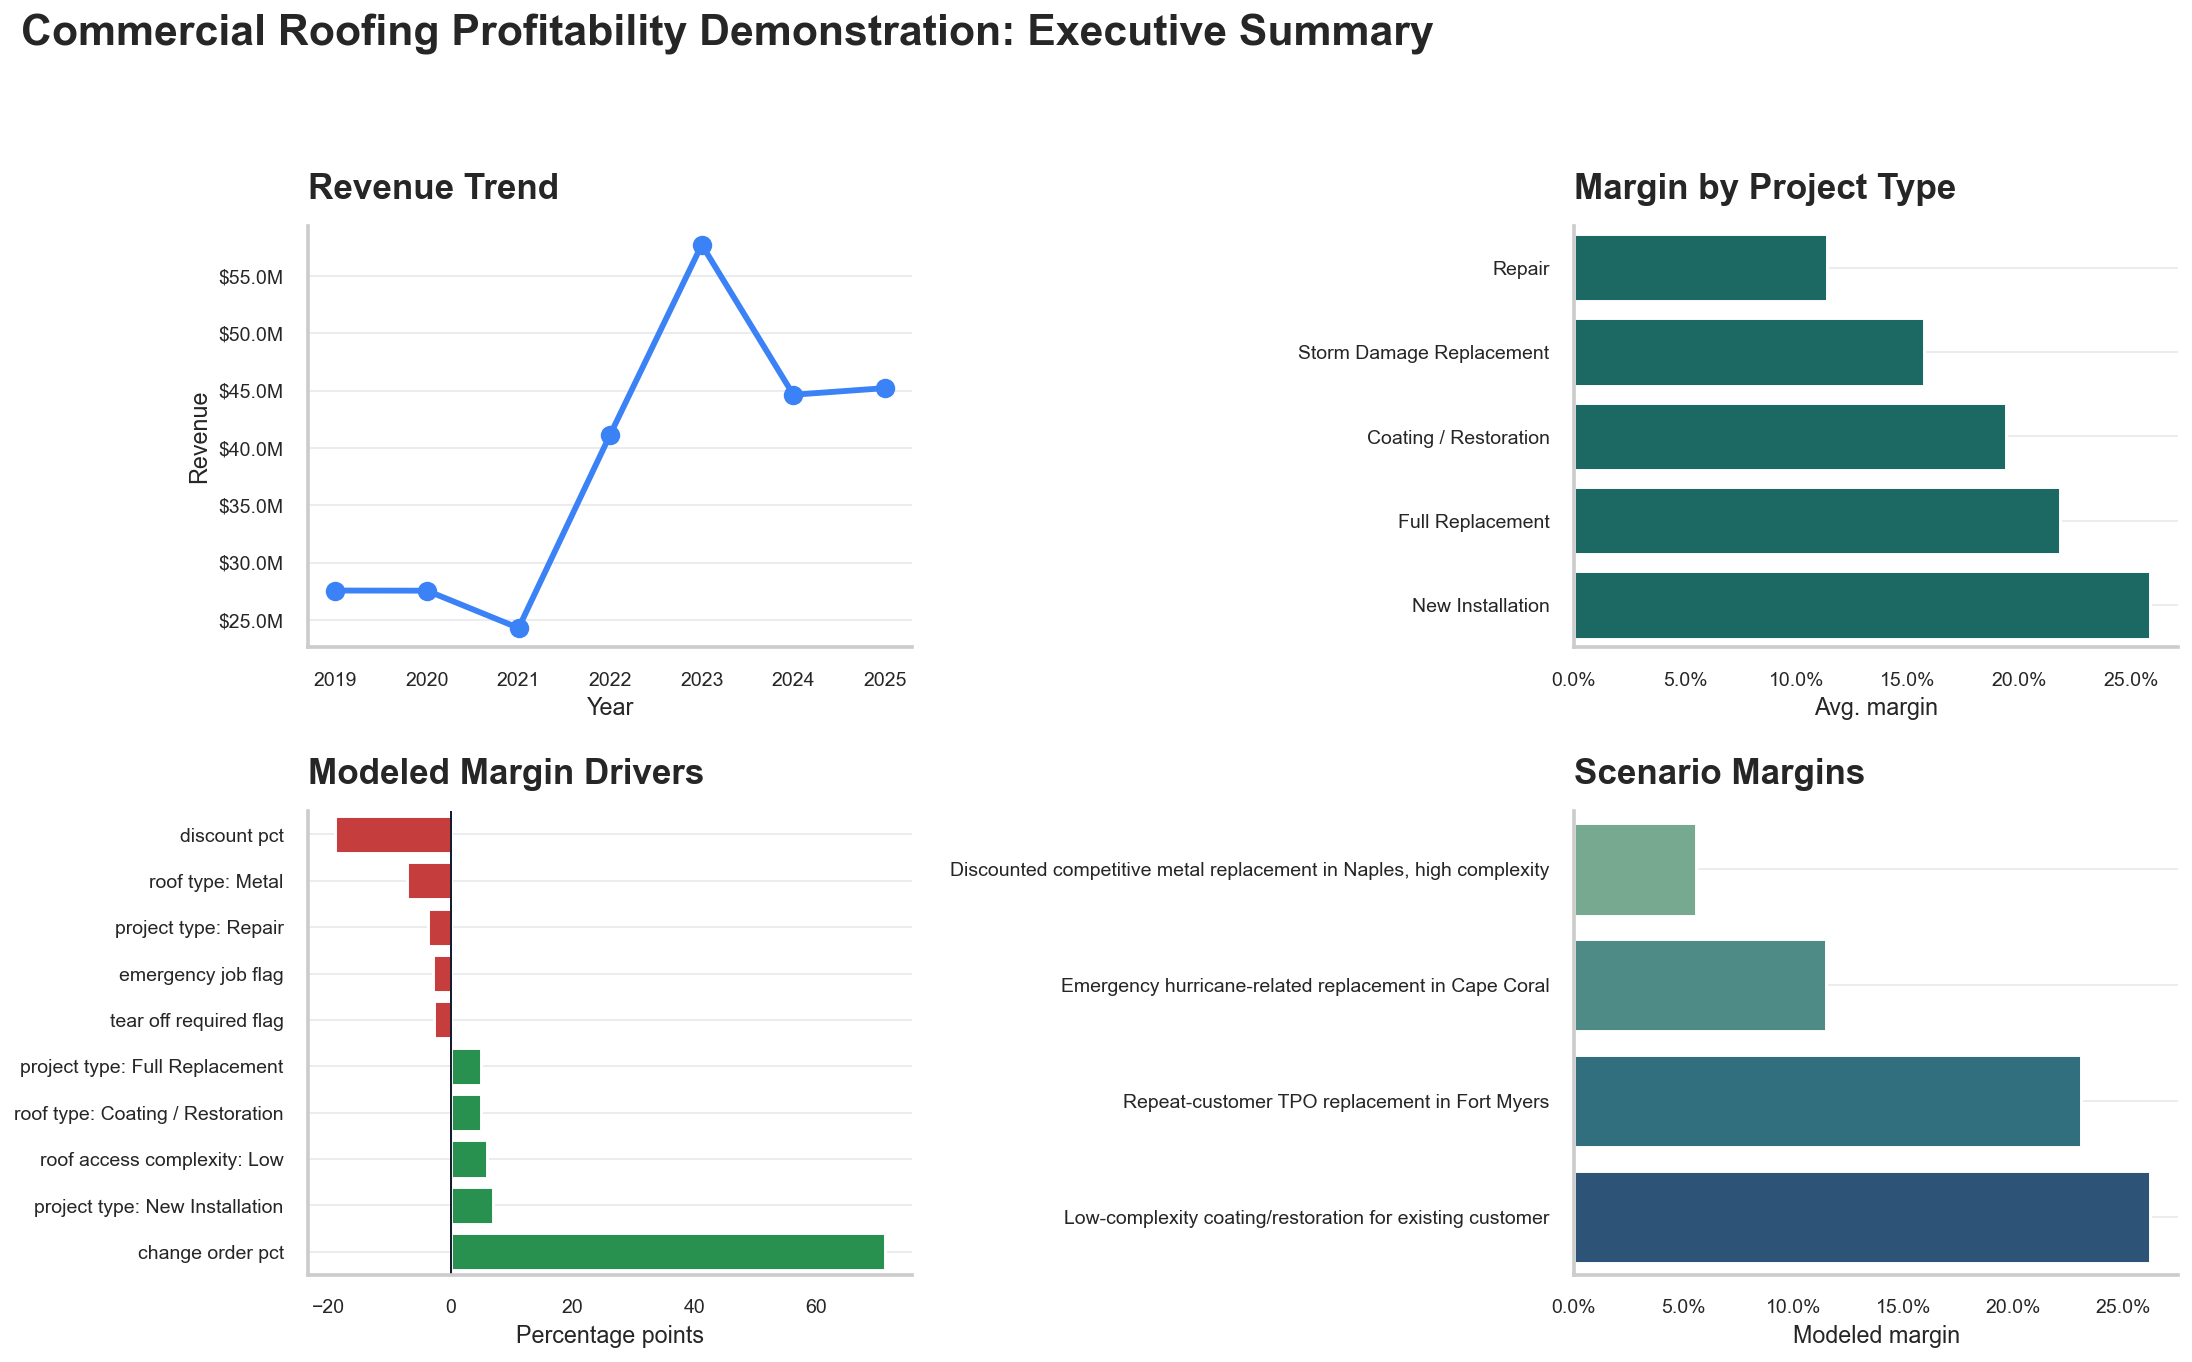

In [19]:
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.1])
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

ax1.plot(annual["year"], annual["realized_revenue"], marker="o", linewidth=3, color=PALETTE["blue"])
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(dollars))
clean_axis(ax1, "Revenue Trend", "Year", "Revenue")

top_types = df.groupby("project_type")["profit_margin_pct"].mean().sort_values()
sns.barplot(x=top_types.values, y=top_types.index, ax=ax2, color=PALETTE["teal"])
ax2.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
clean_axis(ax2, "Margin by Project Type", "Avg. margin", "")

driver_subset = pd.concat([coef2.head(5), coef2.tail(5)]).sort_values("margin_impact_points")
sns.barplot(data=driver_subset, y="business_label", x="margin_impact_points", palette=np.where(driver_subset["margin_impact_points"] >= 0, PALETTE["green"], PALETTE["red"]), ax=ax3)
ax3.axvline(0, color="#0f172a", linewidth=1)
clean_axis(ax3, "Modeled Margin Drivers", "Percentage points", "")

sns.barplot(data=scenarios_plot, y="Scenario", x="Estimated margin", palette="crest", ax=ax4)
ax4.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
clean_axis(ax4, "Scenario Margins", "Modeled margin", "")

fig.suptitle("Commercial Roofing Profitability Demonstration: Executive Summary", x=0.02, ha="left", fontsize=22, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Minimum Actual Data Fields for a Real Analysis

For a real version of this work, the first step would be to pull together the basic operating data behind completed jobs:

- Completed-job history: project ID, dates, town, customer, project type, roof type, size, complexity, and scope notes.
- Estimating data: original estimate, target margin, bid amount, alternates, discounting, competitors, and estimator.
- Job-costing data: labor, material, subcontractor, equipment, permit, disposal, travel, and warranty or rework costs.
- Revenue data: contract value, invoices, change orders, retainage, collections, and write-offs.
- Operational data: planned duration, actual duration, crew size, weather delays, access issues, and production notes.
- Sales and marketing data: lead source, campaign, salesperson, customer type, sales cycle, win/loss reason, and customer relationship history.

## 11. Where Actual Company Data Could Take This Next

This synthetic notebook is useful for showing the approach. The real value would come from applying the same structure to the contractor's own data. A practical next-step roadmap could look like this:

**A. Historical Job Profitability Diagnostic**  
Combine estimate, contract, invoicing, labor, material, subcontractor, schedule, and change-order data to identify where margin is being made or lost.

**B. Estimating and Bid Discipline Tool**  
Build a model that estimates expected margin before a bid is submitted. The goal would be to flag jobs where discounting, travel, complexity, or material exposure make the quote risky, and to support minimum-margin thresholds or recommended pricing adjustments.

**C. Marketing ROI and Lead Source Analysis**  
Connect CRM or lead records to completed-job profitability. This would show which channels create profitable customers, not just leads or booked revenue.

**D. Customer and Market Segmentation**  
Identify which verticals, towns, property types, and customer relationships are most valuable, then use that evidence to guide targeted outreach in Southwest Florida.

**E. Storm Response Profitability Analysis**  
Measure whether hurricane-driven work truly earns a premium after labor constraints, material escalation, subcontractor dependence, delays, and collection timelines.

**F. Dashboard and Ongoing Management Reporting**  
Develop an executive dashboard for backlog, revenue, margin, win rate, lead-source profitability, job overruns, and estimator performance.

**G. Predictive Business Development Targeting**  
Combine market, property, building, roofing-lifecycle, storm exposure, and past-customer data to identify likely future commercial roofing opportunities. Any use of external property or customer data should comply with applicable contracts, privacy obligations, and marketing rules.

The best first step would usually be a structured review of what data the company already has: estimating spreadsheets, accounting and job-costing exports, CRM or lead records, material and labor information, and completed-job history.